<a href="https://colab.research.google.com/github/pramitpal/SNN_2D5/blob/main/SNN_2D5_Grouping_Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Clone Repo
!git clone https://github.com/pramitpal/SNN_2D5.git > /dev/null 2>&1
!cp -a /content/SNN_2D5/. /content/
!rm -rf /content/SNN_2D5
# !curl -L -o snn_mapper.py https://raw.githubusercontent.com/pramitpal/SNN_2D5/main/snn_mapper.py > /dev/null 2>&1

In [ ]:
#@title Group calculation functions V2
def get_layer_lif_distances(chiplet_mapping_data, layer_num, lif_tiles_needed, lif_start_chiplet,
                            lif_tiles_per_chiplet, mesh_rows, mesh_cols, pe_per_tile=40,
                            intra_cost=1, inter_cost=4):
    lif_end_chiplet = lif_start_chiplet + int(np.ceil(lif_tiles_needed / lif_tiles_per_chiplet)) - 1

    for group in chiplet_mapping_data:
        if layer_num in group['Layer_tile_distribution']:
            layer_tile_dist = group['Layer_tile_distribution'][layer_num]
            break
    else:
        layer_tile_dist = {}

    total_distance = 0
    total_compute_pes = 0

    for compute_chiplet, num_tiles in layer_tile_dist.items():
        num_pes = num_tiles * pe_per_tile
        if lif_start_chiplet <= compute_chiplet <= lif_end_chiplet:
            distance = intra_cost
        else:
            compute_row, compute_col = divmod(compute_chiplet, mesh_cols)
            min_manhattan = float('inf')
            for lif_chiplet in range(lif_start_chiplet, lif_end_chiplet + 1):
                lif_row, lif_col = divmod(lif_chiplet, mesh_cols)
                manhattan = abs(compute_row - lif_row) + abs(compute_col - lif_col)
                min_manhattan = min(min_manhattan, manhattan)
            distance = inter_cost * min_manhattan

        total_distance += num_pes * lif_tiles_needed * distance
        total_compute_pes += num_pes

    if total_compute_pes == 0:
        return 0

    return total_distance / total_compute_pes


def calculate_group_cost(chiplet_mapping_data, start_layer, end_layer, start_placing_in_chiplet,
                         lif_tiles_per_chiplet, MEMS, SRAM_KB_per_tile, operations,
                         mesh_rows, mesh_cols, pe_per_tile=40,
                         intra_cost=1, inter_cost=4, bus_width_bits=32,
                         use_congestion_penalty=False, use_mem_footprint_penalty=True):
    LIF_tiles_needed = int(np.ceil((np.array(MEMS[start_layer - 1:end_layer]) / (1024 * SRAM_KB_per_tile)).max()))

    total_cost = 0
    max_MEMS = max(MEMS) if max(MEMS) > 0 else 1

    for layer in range(start_layer, end_layer + 1):
        for group in chiplet_mapping_data:
            if layer in group['Layer_tile_distribution']:
                num_tiles_in_layer = sum(group['Layer_tile_distribution'][layer].values())
                break
        else:
            num_tiles_in_layer = 1  # fallback

        layer_ops = operations[layer - 1]
        total_pes = num_tiles_in_layer * pe_per_tile
        per_pe_traffic = layer_ops / total_pes if total_pes > 0 else 0

        layer_lif_distance = get_layer_lif_distances(
            chiplet_mapping_data, layer, LIF_tiles_needed, start_placing_in_chiplet,
            lif_tiles_per_chiplet, mesh_rows, mesh_cols, pe_per_tile, intra_cost, inter_cost)

        estimated_traffic_bits = per_pe_traffic * total_pes * (layer_lif_distance ** 2)
        traffic_cycles = estimated_traffic_bits / bus_width_bits

        congestion_penalty = 0
        if use_congestion_penalty:
            congestion_penalty = max(0, traffic_cycles - 1) ** 2

        mem_penalty = 0
        if use_mem_footprint_penalty:
            mem_penalty = MEMS[layer - 1] / max_MEMS

        layer_cost = traffic_cycles * (1 + congestion_penalty) * (1 + mem_penalty)
        total_cost += layer_cost

    return total_cost

In [ ]:
# @title Create Groupings + place LIF tiles functions V4 - Complete Rewrite
import numpy as np
import warnings
from itertools import combinations

#--------------------------------------------------------
# Helper: Convert chiplet ID -> (row, col) coordinates
# Supports serpentine numbering: even rows L->R, odd rows R->L
#--------------------------------------------------------
def get_row_col(chiplet_id, mesh_cols, mesh_rows):
    row, col_base = divmod(chiplet_id, mesh_cols)
    if row % 2 == 1:  # Odd row: reverse column mapping
        col = mesh_cols - 1 - col_base
    else:  # Even row: standard
        col = col_base
    return row, col

#--------------------------------------------------------
# Helper: Convert (row, col) -> chiplet ID
#--------------------------------------------------------
def get_chiplet_id(row, col, mesh_cols, mesh_rows):
    if not (0 <= row < mesh_rows and 0 <= col < mesh_cols):
        return None
    base = row * mesh_cols
    if row % 2 == 0:  # Even row: standard
        return base + col
    else:  # Odd row: reverse column
        return base + (mesh_cols - 1 - col)

#--------------------------------------------------------
# Get all chiplets within a given Manhattan distance
#--------------------------------------------------------
def get_mesh_neighbors(chiplet_id, mesh_rows, mesh_cols, max_distance=2):
    row, col = get_row_col(chiplet_id, mesh_cols, mesh_rows)
    neighbors = {d: [] for d in range(max_distance + 1)}
    total_chiplets = mesh_rows * mesh_cols
    for cid in range(total_chiplets):
        r, c = get_row_col(cid, mesh_cols, mesh_rows)
        dist = abs(r - row) + abs(c - col)
        if dist <= max_distance:
            neighbors[dist].append(cid)
    return {d: v for d, v in neighbors.items() if v}

#--------------------------------------------------------
# Identify possible contiguous mesh shapes
#--------------------------------------------------------
def find_mesh_regions(start, count, rows, cols):
    start_r, start_c = get_row_col(start, cols, rows)
    total = rows * cols

    def valid(chips):
        return all(0 <= x < total for x in chips) and len(set(chips)) == count

    shapes = []

    # Horizontal region
    horiz = []
    can_fit_h = True
    for i in range(count):
        cc = start_c + i
        if cc >= cols:
            can_fit_h = False
            break
        chip_id = get_chiplet_id(start_r, cc, cols, rows)
        if chip_id is None:
            can_fit_h = False
            break
        horiz.append(chip_id)
    if can_fit_h and valid(horiz):
        shapes.append(horiz)

    # Vertical region
    vert = []
    can_fit_v = True
    for i in range(count):
        rr = start_r + i
        if rr >= rows:
            can_fit_v = False
            break
        chip_id = get_chiplet_id(rr, start_c, cols, rows)
        if chip_id is None:
            can_fit_v = False
            break
        vert.append(chip_id)
    if can_fit_v and valid(vert):
        shapes.append(vert)

    # L-shapes for count=3
    if count == 3:
        l1_ids = [
            get_chiplet_id(start_r, start_c, cols, rows),
            get_chiplet_id(start_r, start_c + 1, cols, rows) if start_c + 1 < cols else None,
            get_chiplet_id(start_r + 1, start_c, cols, rows) if start_r + 1 < rows else None
        ]
        l1 = [x for x in l1_ids if x is not None]
        if len(l1) == 3 and valid(l1):
            shapes.append(l1)

        l2_ids = [
            get_chiplet_id(start_r, start_c, cols, rows),
            get_chiplet_id(start_r + 1, start_c, cols, rows) if start_r + 1 < rows else None,
            get_chiplet_id(start_r + 1, start_c + 1, cols, rows) if start_r + 1 < rows and start_c + 1 < cols else None
        ]
        l2 = [x for x in l2_ids if x is not None]
        if len(l2) == 3 and valid(l2):
            shapes.append(l2)

    # 2x2 square for count=4
    elif count == 4:
        sq_ids = [
            get_chiplet_id(start_r, start_c, cols, rows),
            get_chiplet_id(start_r, start_c + 1, cols, rows) if start_c + 1 < cols else None,
            get_chiplet_id(start_r + 1, start_c, cols, rows) if start_r + 1 < rows else None,
            get_chiplet_id(start_r + 1, start_c + 1, cols, rows) if start_r + 1 < rows and start_c + 1 < cols else None
        ]
        sq = [x for x in sq_ids if x is not None]
        if len(sq) == 4 and valid(sq):
            shapes.append(sq)

    return [s for s in shapes if valid(s)]

#--------------------------------------------------------
# Analyze crossbar usage for chiplets within layer range
#--------------------------------------------------------
def analyze_crossbar_usage(mapping, start_layer, end_layer, lif_alloc):
    chiplet_usage = {}
    for layer in range(start_layer, end_layer + 1):
        for cid, info in enumerate(mapping):
            if layer in info['Layers_filled']:
                idx = info['Layers_filled'].index(layer)
                used = info['Crossbars_filled_respective_layer'][idx]
                chiplet_usage.setdefault(cid, {})[layer] = used

    total_crossbars = {cid: sum(v.values()) for cid, v in chiplet_usage.items()}
    remaining = {cid: LIF_T - lif_alloc.get(cid, 0) for cid in range(len(mapping))}
    return chiplet_usage, total_crossbars, remaining

#--------------------------------------------------------
# Calculate LIF tiles needed for a layer range
#--------------------------------------------------------
def calculate_lif_tiles_needed(start_layer, end_layer, mems_array, sram_kb_per_tile):
    """Calculate max LIF tiles needed across layer range"""
    tiles_needed = int(np.ceil(
        (np.array(mems_array[start_layer - 1:end_layer]) / (1024 * sram_kb_per_tile)).max()
    ))
    return tiles_needed

#--------------------------------------------------------
# Distribute LIF tiles - STRICT VERSION
# Returns empty list if cannot allocate ALL tiles
#--------------------------------------------------------
def distribute_lif_tiles_strict(available_chiplets, tiles_needed, capacity_map, debug=False):
    """
    Strictly allocate ALL tiles or return empty list.
    """
    if debug:
        print(f"  [DEBUG] Attempting to allocate {tiles_needed} tiles")
        print(f"  [DEBUG] Available chiplets: {sorted(available_chiplets)}")
        print(f"  [DEBUG] Capacities: {[(c, capacity_map.get(c, 0)) for c in sorted(available_chiplets)]}")

    # Check if enough total capacity
    total_capacity = sum(capacity_map.get(c, 0) for c in available_chiplets)
    if total_capacity < tiles_needed:
        if debug:
            print(f"  [DEBUG] FAILED: Total capacity {total_capacity} < needed {tiles_needed}")
        return []

    dist = []
    remaining = tiles_needed

    # Sort by descending capacity
    sorted_chiplets = sorted(available_chiplets, key=lambda c: capacity_map.get(c, 0), reverse=True)

    for cid in sorted_chiplets:
        if remaining <= 0:
            break
        avail = capacity_map.get(cid, 0)
        if avail <= 0:
            continue
        alloc = min(avail, remaining)
        dist.append((cid, alloc))
        remaining -= alloc
        if debug:
            print(f"  [DEBUG] Allocated {alloc} tiles to chiplet {cid}, remaining: {remaining}")

    # Verify complete allocation
    total_allocated = sum(t for _, t in dist)
    if total_allocated < tiles_needed:
        if debug:
            print(f"  [DEBUG] FAILED: Only allocated {total_allocated}/{tiles_needed} tiles")
        return []

    if debug:
        print(f"  [DEBUG] SUCCESS: Allocated all {tiles_needed} tiles across {len(dist)} chiplets")
    return dist

#--------------------------------------------------------
# Compute group cost
#--------------------------------------------------------
def calculate_group_cost_crossbar_weighted(mapping, start, end, region, usage, rows, cols, ops, intra_cost=1, inter_cost=4):
    total_cost = 0
    for layer in range(start, end + 1):
        if layer - 1 >= len(ops):
            continue
        layer_ops = ops[layer - 1]
        chiplets = [(cid, cb.get(layer, 0)) for cid, cb in usage.items() if layer in cb]
        if not chiplets:
            continue
        total_cb = sum(cb for _, cb in chiplets)
        if total_cb == 0:
            continue

        for comp, cb in chiplets:
            if total_cb == 0 or cb == 0:
                continue
            weight = cb / total_cb
            r1, c1 = get_row_col(comp, cols, rows)
            min_dist = min(abs(r1 - r2) + abs(c1 - c2) for lif in region
                           for r2, c2 in [get_row_col(lif, cols, rows)])
            cost_val = intra_cost if min_dist == 0 else inter_cost * min_dist
            total_cost += layer_ops * cost_val * weight
    return total_cost

#--------------------------------------------------------
# Find optimal LIF placement - STRICT VERSION
#--------------------------------------------------------
def find_optimal_lif_placement_strict(mapping, start, end, tiles_needed, tiles_per_ch, rows, cols,
                                     available_chiplets, lif_alloc, inter_cost=4, debug=False):
    """
    Find optimal placement ensuring ALL tiles are allocated.
    Returns (distribution, cost) or ([], inf) if impossible.
    """
    if debug:
        print(f"\n[DEBUG] ===== Placement for layers {start}-{end} =====")
        print(f"[DEBUG] Tiles needed: {tiles_needed}")
        print(f"[DEBUG] Available chiplets: {len(available_chiplets)}")

    if not available_chiplets:
        if debug:
            print(f"[DEBUG] No available chiplets!")
        return [], float('inf')

    if tiles_needed <= 0:
        if debug:
            print(f"[DEBUG] No tiles needed, returning empty distribution")
        return [], 0

    # Calculate remaining capacity for each chiplet
    capacity = {c: LIF_T - lif_alloc.get(c, 0) for c in available_chiplets}

    # Filter out chiplets with no capacity
    capacity = {c: cap for c, cap in capacity.items() if cap > 0}
    available_chiplets = set(capacity.keys())

    if not available_chiplets:
        if debug:
            print(f"[DEBUG] No chiplets with remaining capacity!")
        return [], float('inf')

    total_capacity = sum(capacity.values())
    if debug:
        print(f"[DEBUG] Total available capacity: {total_capacity}")

    if total_capacity < tiles_needed:
        if debug:
            print(f"[DEBUG] Insufficient total capacity: {total_capacity} < {tiles_needed}")
        return [], float('inf')

    # Analyze crossbar usage
    usage, total_cb, _ = analyze_crossbar_usage(mapping, start, end, lif_alloc)

    # If no crossbar data, use simple allocation
    if not total_cb:
        if debug:
            print(f"[DEBUG] No crossbar data, using simple allocation")
        dist = distribute_lif_tiles_strict(available_chiplets, tiles_needed, capacity, debug)
        if not dist:
            return [], float('inf')
        return dist, 0

    # Filter to only available chiplets with crossbar activity
    total_cb = {k: v for k, v in total_cb.items() if k in available_chiplets}

    if not total_cb:
        if debug:
            print(f"[DEBUG] No crossbar activity in available chiplets, using simple allocation")
        dist = distribute_lif_tiles_strict(available_chiplets, tiles_needed, capacity, debug)
        if not dist:
            return [], float('inf')
        return dist, 0

    # Find main chiplet with highest activity
    main_chip = max(total_cb, key=total_cb.get)
    neighbors = get_mesh_neighbors(main_chip, rows, cols)

    # Build priority list
    priority = [main_chip]
    others = sorted([c for c in total_cb if c != main_chip],
                    key=lambda c: total_cb[c], reverse=True)
    priority.extend(others)
    for dist in [1, 2]:
        priority.extend([c for c in neighbors.get(dist, []) if c in available_chiplets and c not in priority])

    # Estimate chiplets needed
    chiplets_needed = max(1, int(np.ceil(tiles_needed / tiles_per_ch)))

    # Find candidate regions
    candidate_regions = []
    avail_set = set(available_chiplets)

    for start_chip in priority:
        for size in range(chiplets_needed, min(chiplets_needed + 3, len(available_chiplets) + 1)):
            for region in find_mesh_regions(start_chip, size, rows, cols):
                if avail_set.issuperset(region):
                    region_capacity = sum(capacity.get(c, 0) for c in region)
                    if region_capacity >= tiles_needed:
                        if sorted(region) not in [sorted(r) for r in candidate_regions]:
                            candidate_regions.append(region)

    # Fallback: create region from highest capacity chiplets
    if not candidate_regions:
        if debug:
            print(f"[DEBUG] No valid contiguous regions, using capacity-based fallback")
        region = []
        accumulated = 0
        for cid in sorted(available_chiplets, key=lambda c: capacity.get(c, 0), reverse=True):
            region.append(cid)
            accumulated += capacity.get(cid, 0)
            if accumulated >= tiles_needed:
                break
        if accumulated >= tiles_needed:
            candidate_regions.append(region)

    if not candidate_regions:
        if debug:
            print(f"[DEBUG] Could not form any valid region")
        return [], float('inf')

    # Evaluate all candidate regions
    best_dist, best_cost = None, float('inf')

    for region in candidate_regions:
        # Try to allocate tiles in this region
        dist = distribute_lif_tiles_strict(region, tiles_needed, capacity, debug=False)
        if not dist:
            continue

        # Calculate cost
        cost = calculate_group_cost_crossbar_weighted(mapping, start, end, region, usage,
                                                     rows, cols, mapper.TOPS, inter_cost=inter_cost)

        if cost < best_cost:
            best_cost = cost
            best_dist = dist

    if best_dist is None:
        if debug:
            print(f"[DEBUG] No valid allocation found in any region")
        return [], float('inf')

    if debug:
        print(f"[DEBUG] Found allocation with cost {best_cost}: {best_dist}")

    return best_dist, best_cost

#--------------------------------------------------------
# Main grouping function - REWRITTEN WITH COVERAGE CHECK
#--------------------------------------------------------
def find_optimal_groupings_mesh_aware(total_layers, mesh_rows, mesh_cols,
                                     threshold_multiplier=2.0,
                                     placement_strategy='exclusive',
                                     allow_reuse=False,
                                     inter_cost=4,
                                     debug=False):
    """
    Create layer groupings ensuring:
    1. Every group has complete LIF tile allocation
    2. All layers from 1 to total_layers are covered
    3. Groups with incomplete allocation are discarded
    4. If not all layers can be covered, return empty list
    """
    if debug:
        print(f"\n{'='*80}")
        print(f"Starting grouping: {total_layers} layers, {mesh_rows}x{mesh_cols} mesh")
        print(f"Strategy: {placement_strategy}, Threshold multiplier: {threshold_multiplier}")
        print(f"{'='*80}\n")

    # Validate mesh capacity
    total_chiplets = mesh_rows * mesh_cols
    required_chiplets = len(mapper.chiplet_data)

    if required_chiplets > total_chiplets:
        print(f"ERROR: Mapping requires {required_chiplets} chiplets, mesh has {total_chiplets}")
        return []

    all_groups = []
    available = set(range(total_chiplets))
    lif_alloc = {i: 0 for i in range(total_chiplets)}
    start_layer = 1
    failed_allocation = False

    while start_layer <= total_layers:
        if debug:
            print(f"\n[DEBUG] ----- Processing from layer {start_layer} -----")
            print(f"[DEBUG] Available chiplets: {len(available)}")
            total_remaining = sum(LIF_T - lif_alloc.get(c, 0) for c in available)
            print(f"[DEBUG] Total remaining LIF capacity: {total_remaining}")

        # Check if we have any capacity left
        if not available and placement_strategy == 'exclusive':
            if debug:
                print(f"[DEBUG] No available chiplets, cannot process layers {start_layer}-{total_layers}")
            print(f"ERROR: Cannot allocate layers {start_layer}-{total_layers} - no chiplets available")
            failed_allocation = True
            break

        # Calculate costs for incremental groupings
        costs = []
        tiles_list = []
        marginals = []

        for end_layer in range(start_layer, total_layers + 1):
            tiles_needed = calculate_lif_tiles_needed(start_layer, end_layer, mapper.MEMS, SRAM_KB_per_tile)
            tiles_list.append(tiles_needed)

            # Calculate cost using a dummy chiplet
            dummy = min(available) if available else 0
            cost = calculate_group_cost(mapper.chiplet_data, start_layer, end_layer, dummy, LIF_T,
                                       mapper.MEMS, SRAM_KB_per_tile, mapper.TOPS,
                                       mesh_rows, mesh_cols, intra_cost=1, inter_cost=inter_cost)
            costs.append(cost)

            if len(costs) > 1:
                marginals.append(costs[-1] - costs[-2])

        # Case 1: Only one layer left (base case)
        if start_layer == total_layers:
            if debug:
                print(f"[DEBUG] Final single layer {start_layer}")

            dist, opt_cost = find_optimal_lif_placement_strict(
                mapper.chiplet_data, start_layer, total_layers, tiles_list[0],
                LIF_T, mesh_rows, mesh_cols, available, lif_alloc, inter_cost=inter_cost, debug=debug)

            if dist:
                all_groups.append({
                    'start_layer': start_layer,
                    'end_layer': total_layers,
                    'lif_tiles': tiles_list[0],
                    'lif_distribution': dist,
                    'cost': opt_cost
                })
                # Update allocations
                for c, t in dist:
                    lif_alloc[c] += t
                    if placement_strategy == 'exclusive' and not allow_reuse:
                        if lif_alloc[c] >= LIF_T:
                            available.discard(c)
            else:
                print(f"ERROR: Cannot allocate final layer {start_layer}")
                failed_allocation = True
            break

        # Case 2: Find break point using marginal costs
        valid_marginals = [m for m in marginals if np.isfinite(m)]

        if not valid_marginals:
            # All costs are infinite - try to allocate everything as one group
            if debug:
                print(f"[DEBUG] All marginals infinite, trying single group for {start_layer}-{total_layers}")

            dist, opt_cost = find_optimal_lif_placement_strict(
                mapper.chiplet_data, start_layer, total_layers, tiles_list[-1],
                LIF_T, mesh_rows, mesh_cols, available, lif_alloc, inter_cost=inter_cost, debug=debug)

            if dist:
                all_groups.append({
                    'start_layer': start_layer,
                    'end_layer': total_layers,
                    'lif_tiles': tiles_list[-1],
                    'lif_distribution': dist,
                    'cost': opt_cost
                })
                for c, t in dist:
                    lif_alloc[c] += t
                    if placement_strategy == 'exclusive' and not allow_reuse:
                        if lif_alloc[c] >= LIF_T:
                            available.discard(c)
            else:
                print(f"ERROR: Cannot allocate remaining layers {start_layer}-{total_layers}")
                failed_allocation = True
            break

        threshold = np.mean(valid_marginals) + threshold_multiplier * np.std(valid_marginals)
        break_found = False

        if debug:
            print(f"[DEBUG] Marginal cost threshold: {threshold:.2f}")

        # Look for threshold break
        for i, mc in enumerate(marginals):
            if np.isinf(mc):
                continue

            if mc > threshold:
                br_layer = start_layer + i
                if debug:
                    print(f"[DEBUG] Break found at layer {br_layer} (marginal cost: {mc:.2f})")

                dist, opt_cost = find_optimal_lif_placement_strict(
                    mapper.chiplet_data, start_layer, br_layer, tiles_list[i],
                    LIF_T, mesh_rows, mesh_cols, available, lif_alloc, inter_cost=inter_cost, debug=debug)

                if dist:
                    all_groups.append({
                        'start_layer': start_layer,
                        'end_layer': br_layer,
                        'lif_tiles': tiles_list[i],
                        'lif_distribution': dist,
                        'cost': opt_cost
                    })
                    for c, t in dist:
                        lif_alloc[c] += t
                        if placement_strategy == 'exclusive' and not allow_reuse:
                            if lif_alloc[c] >= LIF_T:
                                available.discard(c)
                    start_layer = br_layer + 1
                    break_found = True
                else:
                    print(f"ERROR: Failed to allocate group {start_layer}-{br_layer}")
                    failed_allocation = True
                    break_found = True
                break

        if failed_allocation:
            break

        # No break found - make one final group
        if not break_found:
            if debug:
                print(f"[DEBUG] No break found, creating final group {start_layer}-{total_layers}")

            dist, opt_cost = find_optimal_lif_placement_strict(
                mapper.chiplet_data, start_layer, total_layers, tiles_list[-1],
                LIF_T, mesh_rows, mesh_cols, available, lif_alloc, inter_cost=inter_cost, debug=debug)

            if dist:
                all_groups.append({
                    'start_layer': start_layer,
                    'end_layer': total_layers,
                    'lif_tiles': tiles_list[-1],
                    'lif_distribution': dist,
                    'cost': opt_cost
                })
                for c, t in dist:
                    lif_alloc[c] += t
                    if placement_strategy == 'exclusive' and not allow_reuse:
                        if lif_alloc[c] >= LIF_T:
                            available.discard(c)
            else:
                print(f"ERROR: Cannot allocate final group {start_layer}-{total_layers}")
                failed_allocation = True
            break

    # CRITICAL CHECK: Verify all layers are covered
    covered_layers = set()
    for g in all_groups:
        covered_layers.update(range(g['start_layer'], g['end_layer'] + 1))

    missing_layers = set(range(1, total_layers + 1)) - covered_layers

    if missing_layers or failed_allocation:
        print(f"\n{'='*80}")
        print(f"GROUPING FAILED - NOT ALL LAYERS COVERED")
        print(f"{'='*80}")
        if missing_layers:
            print(f"Missing layers: {sorted(missing_layers)}")
        print(f"Only covered layers 1-{max(covered_layers) if covered_layers else 0} out of {total_layers}")
        print(f"Discarding incomplete grouping and returning empty list.")
        print(f"{'='*80}\n")
        return []

    # Final validation
    if debug:
        print(f"\n{'='*80}")
        print(f"Grouping SUCCESS: {len(all_groups)} groups created")
        print(f"All {total_layers} layers covered")
        print(f"{'='*80}\n")

    # Validate each group
    for i, g in enumerate(all_groups):
        allocated = sum(t for _, t in g['lif_distribution'])
        if allocated < g['lif_tiles']:
            print(f"WARNING: Group {i} (layers {g['start_layer']}-{g['end_layer']}): "
                  f"allocated {allocated}/{g['lif_tiles']} tiles - INCOMPLETE")
        elif debug:
            print(f"[DEBUG] Group {i} (layers {g['start_layer']}-{g['end_layer']}): "
                  f"allocated {allocated}/{g['lif_tiles']} tiles - OK")

    return all_groups

#--------------------------------------------------------
# Format output
#--------------------------------------------------------
def format_output(groups):
    return [[list(range(g['start_layer'], g['end_layer'] + 1)), g['lif_distribution']] for g in groups]

In [ ]:
#@title Visualize groupings + LIF placements as mesh function v2
def visualize_groups(all_groups, chiplet_mapping_data, mesh_rows, mesh_cols, LIF_T=16, invert_yaxis=True, max_lines=4, auto_display=False):
    """
    Visualize layer groupings and LIF allocation in chiplet mesh format.
    Enhanced to prevent text spilling and duplicate displays.

    Args:
        all_groups (list): List of dicts with 'start_layer', 'end_layer', 'lif_distribution' (list of (chiplet, tiles)).
        chiplet_mapping_data (list): List of dicts, indexed by chiplet ID, each with 'Layers_filled' (list of ints).
        mesh_rows (int), mesh_cols (int): Mesh dimensions.
        LIF_T (int, optional): Total LIF tiles per chiplet. Defaults to 16.
        invert_yaxis (bool, optional): If True, place row 0 at top. Defaults to True.
        max_lines (int, optional): Max lines in annotations before truncating. Defaults to 4.
        auto_display (bool, optional): If True, call plt.show() (for scripts). In Jupyter, set False for inline auto-display. Defaults to True.

    Returns:
        matplotlib.figure.Figure: The figure object (for saving, e.g., fig.savefig('mesh.png')).
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    # Close all existing figures to prevent duplicates
    plt.close('all')

    total_chiplets = mesh_rows * mesh_cols

    # Create larger figure to reduce crowding/spilling
    fig, ax = plt.subplots(figsize=(16, 12))

    # Colors for groups
    num_groups = len(all_groups)
    colors = plt.cm.tab10(np.linspace(0, 1, num_groups)) if num_groups > 0 else []

    # Get physical layers per chiplet (with safety)
    physical_layers = {}
    for chiplet_id in range(total_chiplets):
        if chiplet_id < len(chiplet_mapping_data):
            physical_layers[chiplet_id] = chiplet_mapping_data[chiplet_id].get('Layers_filled', [])
        else:
            physical_layers[chiplet_id] = []

    # Get LIF allocation per chiplet (aggregate across groups)
    chiplet_lif_by_group = {i: {} for i in range(total_chiplets)}
    for g_idx, group in enumerate(all_groups):
        for chiplet, tiles in group.get('lif_distribution', []):
            if 0 <= chiplet < total_chiplets:
                chiplet_lif_by_group[chiplet][g_idx] = float(tiles)

    # Draw mesh with serpentine chiplet ID mapping
    for row in range(mesh_rows):
        for col in range(mesh_cols):
            # Serpentine mapping: odd rows go right-to-left
            if row % 2 == 0:
                chiplet_id = row * mesh_cols + col
                display_col = col
            else:
                chiplet_id = row * mesh_cols + (mesh_cols - 1 - col)
                display_col = col

            # Determine color and edge
            groups_in_chiplet = list(chiplet_lif_by_group[chiplet_id].keys())
            has_layers = bool(physical_layers[chiplet_id])
            has_lif = bool(groups_in_chiplet)

            if len(groups_in_chiplet) > 1:
                color = 'orange'
                edge = 'red'
                lw = 3
            elif has_lif:
                color = colors[groups_in_chiplet[0]]
                edge = 'black'
                lw = 2
            elif has_layers:
                color = 'lightblue'
                edge = 'black'
                lw = 1.5
            else:
                color = 'lightgray'
                edge = 'black'
                lw = 1

            # Rectangle (slightly smaller for padding)
            rect_width, rect_height = 0.92, 0.92
            rect = plt.Rectangle((display_col + (1-rect_width)/2, row + (1-rect_height)/2),
                                rect_width, rect_height,
                                facecolor=color, edgecolor=edge, linewidth=lw, alpha=0.7)
            ax.add_patch(rect)

            # Build abbreviated text lines
            lines = [f"C{chiplet_id}"]

            # Abbreviated Physical layers
            layers = sorted(physical_layers[chiplet_id])
            if layers:
                if len(layers) <= 3:
                    layer_str = ','.join([f"L{l}" for l in layers])
                else:
                    num_layers = len(layers)
                    min_l, max_l = min(layers), max(layers)
                    layer_str = f"L{min_l}-{max_l}({num_layers})"
                lines.append(f"{layer_str}")

            # Summarized LIF allocation
            total_lif = 0.0
            if chiplet_lif_by_group[chiplet_id]:
                group_details = []
                for g_idx, tiles in sorted(chiplet_lif_by_group[chiplet_id].items()):
                    total_lif += tiles
                    group_details.append(f"G{g_idx+1}:{tiles:.1f}t")

                if len(group_details) <= 2:
                    for detail in group_details:
                        lines.append(detail)
                else:
                    lines.append(f"{group_details[0]}")
                    lines.append(f"+{len(group_details)-1} more")

                # Total LIF if multiple groups
                if len(group_details) > 1:
                    lines.append(f"Σ:{total_lif:.1f}t")

            # Truncate to max_lines
            if len(lines) > max_lines:
                lines = lines[:max_lines-1] + ["..."]

            # Calculate adaptive fontsize based on content
            num_lines = len(lines)
            max_chars = max(len(line) for line in lines)

            # Adaptive sizing: fewer lines and shorter text = bigger font
            if num_lines <= 2 and max_chars <= 8:
                fontsize = 10
            elif num_lines <= 3 and max_chars <= 12:
                fontsize = 8
            elif num_lines <= 4 and max_chars <= 15:
                fontsize = 7
            else:
                fontsize = 6

            # Add text with constrained bbox
            text_str = '\n'.join(lines)
            ax.text(display_col + 0.5, row + 0.5, text_str,
                    ha='center', va='center', fontsize=fontsize, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.15", facecolor='white', alpha=0.85,
                              edgecolor='none'),
                    wrap=True, clip_on=True)

    # Axes setup
    ax.set_xlim(0, mesh_cols)
    ax.set_ylim(0, mesh_rows)
    ax.set_aspect('equal')
    ax.set_xlabel('Column', fontsize=12)
    ax.set_ylabel('Row', fontsize=12)
    ax.set_title('Chiplet Mesh: Layer Groups & LIF Allocation', fontsize=14, fontweight='bold')
    ax.set_xticks(range(mesh_cols))
    ax.set_yticks(range(mesh_rows))
    ax.grid(True, color='white', linewidth=0.5, alpha=0.3)
    if invert_yaxis:
        ax.invert_yaxis()

    # Legend - show ALL groups including those without LIF
    legend_elements = []
    for i, group in enumerate(all_groups):
        dist = group.get('lif_distribution', [])
        start_layer = group['start_layer']
        end_layer = group['end_layer']

        if dist:
            # Groups with LIF allocation
            label = f"G{i+1}: Layers {start_layer}-{end_layer}"
            legend_elements.append(
                mpatches.Patch(facecolor=colors[i] if num_groups > 0 else 'gray',
                              edgecolor='black', alpha=0.7, label=label)
            )
        else:
            # Groups without LIF allocation (like your 35-112 case)
            label = f"G{i+1}: Layers {start_layer}-{end_layer} (No LIF)"
            legend_elements.append(
                mpatches.Patch(facecolor='white', edgecolor='gray',
                              linestyle='--', linewidth=1.5, alpha=0.6, label=label)
            )

    # Add status indicators
    if any(len(chiplet_lif_by_group[i]) > 1 for i in range(total_chiplets)):
        legend_elements.append(
            mpatches.Patch(facecolor='orange', edgecolor='red', linewidth=3, alpha=0.7,
                          label="Shared by multiple groups")
        )
    legend_elements.append(
        mpatches.Patch(facecolor='lightblue', edgecolor='black', alpha=0.7,
                      label="Compute-only (no LIF)")
    )

    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)

    plt.tight_layout()

    if auto_display:
        plt.show()

    return fig

In [ ]:
#@title add_LIF tiles to chiplet mapping function
import copy
def add_lif_tiles(chiplet_mapping, groupings, NT, LIF_T, NPE, mesh_rows, mesh_cols):
    chiplets = copy.deepcopy(chiplet_mapping)
    MAX_CHIPLETS = mesh_rows * mesh_cols
    need = max([cid for g in groupings for cid, _ in g['lif_distribution']], default=-1) + 1
    assert need <= MAX_CHIPLETS, "lif_distribution references a chiplet beyond mesh size."

    while len(chiplets) < need:
        chiplets.append({
            'Layers_filled': [],
            'Crossbars_filled_respective_layer': [],
            'Crossbars_remaining_respective_layer': [],
            'Layer_tile_distribution': {},
            'Empty_crossbars': (NT - LIF_T) * NPE
        })

    next_tile = {}
    lif_id = 0
    for g in groupings:
        for chiplet_id, num_tiles in g['lif_distribution']:
            ltd = chiplets[chiplet_id].setdefault('Layer_tile_distribution', {})
            start = next_tile.get(chiplet_id, NT - LIF_T)
            ltd[f"LIF{lif_id}"] = {i: NPE for i in range(start, start + num_tiles)}
            next_tile[chiplet_id] = start + num_tiles
        lif_id += 1

    return chiplets

In [ ]:
#@title get layer input + output function
import math
import numpy as np

def get_layer_traffic(
    layer_id,
    chiplet_data,
    groupings,
    weights,
    tunable_params,
    xbars,
    X, Vmem_res, Timestep, NoC_buswidth,
    lif_tiles_per_layer,
    SRAM_KB_per_tile,
    acc_enabled=False
):
    """
    Returns a dict:
      {
        "output": [ [src, dst, packets, src_chiplet, dst_chiplet], ... ],
        "input" : [ [src, dst, packets, src_chiplet, dst_chiplet], ... ]
      }

    Output (unchanged):
      - Tile -> (ACC{g})? -> LIF tiles (capacity-aware, fill-first).
      - Single-shot in bits; scaled to packets at end.

    Input (broadcast update):
      - Recompute prev layer's actual LIF writes (in bits).
      - For each destination tile in this layer, pull a FULL prev_OFM in bits:
          tile_quota_bits = IFM_H_prev * IFM_W_prev * OC_prev * Vmem_res
      - Split that quota across prev LIF tiles PROPORTIONALLY to how layer (L-1) wrote them.
      - Do NOT consume LIF supply across tiles (broadcast read).
      - Scale to packets at the end.
    """

    # --------------------------- helpers (bits, no scaling) ---------------------------
    def _group_index_for(layer):
        for gi, g in enumerate(groupings):
            if g['start_layer'] <= layer <= g['end_layer']:
                return gi
        return None

    def _lif_tiles_for_group(gidx):
        name = f"LIF{gidx}"
        tiles = []
        for c_id, chiplet in enumerate(chiplet_data):
            lif_map = chiplet.get('Layer_tile_distribution', {}).get(name, {})
            for t_id in sorted(lif_map.keys()):
                tiles.append((c_id, t_id))
        return name, tiles

    def _traffic_bits_params(li):
        IFM_H, IFM_W = weights[li][0], weights[li][1]
        OC        = weights[li][5]
        total_ofm = IFM_H * IFM_W * OC
        total_xb  = int(xbars[li])
        denom     = (X * max(1, OC))
        per_tp    = max(1, tunable_params[li])
        cb_per_col= max(1, int(math.ceil(per_tp / denom)))
        num_cols  = max(1, int(math.ceil(max(1, total_xb) / cb_per_col)))
        ofm_per_c = total_ofm / 1
        base_bits = ofm_per_c * max(1, Vmem_res)  # single-shot bits per tile under your current model
        return base_bits

    # Compute OUTPUT edges in bits for a given layer and aggregate per-LIF writes (bits)
    def _compute_output_bits_for_layer(layer, acc_mode):
        gidx = _group_index_for(layer)
        if gidx is None:
            return [[f"T?_{layer}", "LIF_NOT_FOUND", 0, "NOT_FOUND", "NOT_FOUND"]], {}

        lif_name, lif_all = _lif_tiles_for_group(gidx)
        if not lif_all:
            return [[f"T?_{layer}", "LIF_NOT_FOUND", 0, "NOT_FOUND", "NOT_FOUND"]], {}

        li = layer - 1
        need = max(1, min(int(lif_tiles_per_layer[li]), len(lif_all)))
        lif_used = lif_all[:need]
        lif_cap_bits = int(SRAM_KB_per_tile) * 1024 * 8

        base_bits = _traffic_bits_params(li)
        results_bits = []
        lif_written_bits = {(c,t): 0.0 for (c,t) in lif_used}

        if acc_mode:
            # single ACC per group on first LIF chiplet
            acc_name = f"ACC{gidx}"
            acc_chip = lif_used[0][0]
            total_into_acc = 0.0

            # Tiles -> ACC
            for c_id, chiplet in enumerate(chiplet_data):
                ltd = chiplet.get('Layer_tile_distribution', {})
                if layer not in ltd:
                    continue
                for tile_id, _cb in ltd[layer].items():
                    src = f"T{tile_id}"
                    results_bits.append([src, acc_name, base_bits, c_id, acc_chip])
                    total_into_acc += base_bits

            # ACC -> LIF (fill-first)
            remaining = total_into_acc
            for (dst_c, lif_tid) in lif_used:
                if remaining <= 0:
                    break
                space = lif_cap_bits - lif_written_bits[(dst_c, lif_tid)]
                if space <= 0:
                    continue
                assign = min(remaining, space)
                lif_written_bits[(dst_c, lif_tid)] += assign
                results_bits.append([acc_name, f"{lif_name}_{lif_tid}", assign, acc_chip, dst_c])
                remaining -= assign
            return results_bits, lif_written_bits

        else:
            # direct Tile -> LIF (fill-first per tile)
            for c_id, chiplet in enumerate(chiplet_data):
                ltd = chiplet.get('Layer_tile_distribution', {})
                if layer not in ltd:
                    continue
                for tile_id, _cb in ltd[layer].items():
                    remaining = base_bits
                    for (dst_c, lif_tid) in lif_used:
                        if remaining <= 0:
                            break
                        space = lif_cap_bits - lif_written_bits[(dst_c, lif_tid)]
                        if space <= 0:
                            continue
                        assign = min(remaining, space)
                        lif_written_bits[(dst_c, lif_tid)] += assign
                        results_bits.append([f"T{tile_id}", f"{lif_name}_{lif_tid}", assign, c_id, dst_c])
                        remaining -= assign
            return results_bits, lif_written_bits

    # ----------------------------------------------------------------------
    # PART 1: OUTPUT for this layer (bits)
    # ----------------------------------------------------------------------
    results_output_bits, _lif_written_cur = _compute_output_bits_for_layer(layer_id, acc_enabled)

    # ----------------------------------------------------------------------
    # PART 2: INPUT for this layer (BROADCAST from prev LIF tiles)
    # ----------------------------------------------------------------------
    results_input_bits = []
    if layer_id > 1:
        prev_layer = layer_id - 1

        # Previous layer's actual LIF writes (in bits)
        _prev_out_bits, prev_lif_written_bits = _compute_output_bits_for_layer(prev_layer, acc_enabled)

        # Build deterministic list of prev LIF tiles that actually have data
        supply_list = [((c,t), bits) for (c,t), bits in prev_lif_written_bits.items() if bits > 0]
        supply_list.sort(key=lambda x: (x[0][0], x[0][1]))  # by (chiplet, tile_id)

        total_prev_written_bits = sum(bits for _, bits in supply_list)

        # Per-tile QUOTA in bits: full prev OFM per tile
        pj = prev_layer - 1
        prev_IFM_H, prev_IFM_W, prev_OC = weights[pj][0], weights[pj][1], weights[pj][5]
        tile_quota_bits = float(prev_IFM_H) * float(prev_IFM_W) * float(prev_OC) * float(max(1, Vmem_res))

        # Destination tiles of current layer (deterministic order)
        dest_tiles = []
        for c_id, chiplet in enumerate(chiplet_data):
            ltd = chiplet.get('Layer_tile_distribution', {})
            if layer_id in ltd:
                for t_id in sorted(ltd[layer_id].keys()):
                    dest_tiles.append((c_id, t_id))

        # If there is no prev data or no destinations, skip
        if total_prev_written_bits > 0 and dest_tiles:
            # Precompute proportional weights of prev LIF tiles
            # w_i = bits_i / total_prev_written_bits
            weights_list = []
            for (c,t), bits in supply_list:
                w = bits / float(total_prev_written_bits)
                weights_list.append(((c,t), w))

            # For each destination tile, allocate the SAME quota following those proportions
            prev_gidx = _group_index_for(prev_layer)
            for (dst_c, dst_t) in dest_tiles:
                # First pass: floor allocation
                alloc = []
                sum_floor = 0.0
                for (src_ct, w) in weights_list:
                    amt = w * tile_quota_bits
                    amt_floor = math.floor(amt)
                    alloc.append([src_ct, amt_floor])
                    sum_floor += amt_floor
                # Residual to reach exactly tile_quota_bits
                residual = int(max(0, math.ceil(tile_quota_bits - sum_floor)))
                # Distribute the residual (largest fractional parts first)
                fracs = [ (i, (weights_list[i][1] * tile_quota_bits) - alloc[i][1]) for i in range(len(alloc)) ]
                fracs.sort(key=lambda x: x[1], reverse=True)
                i = 0
                while residual > 0 and i < len(fracs):
                    idx = fracs[i][0]
                    alloc[idx][1] += 1
                    residual -= 1
                    i += 1

                # Emit per-LIF edges for this destination tile
                for (src_ct, amt_bits) in alloc:
                    if amt_bits <= 0:
                        continue
                    src_c, src_t = src_ct
                    results_input_bits.append([f"LIF{prev_gidx}_{src_t}", f"T{dst_t}", amt_bits, src_c, dst_c])

    # ----------------------------------------------------------------------
    # SCALE BOTH DIRECTIONS: packets = ceil(bits * Timestep / NoC_buswidth)
    # ----------------------------------------------------------------------
    def _scale_to_packets(edges_bits):
        ts = max(1, int(Timestep))
        bw = max(1, int(NoC_buswidth))
        out = []
        for s, d, bits, sc, dc in edges_bits:
            packets = int(math.ceil((bits * ts) / bw))
            out.append([s, d, packets, sc, dc])
        return out

    return {
        "output": _scale_to_packets(results_output_bits),
        "input":  _scale_to_packets(results_input_bits)
    }

In [ ]:
#@title create NOI traffic matrix function
import numpy as np
import pandas as pd

def create_system_matrix_from_edges(all_edge_lists, count_diagonal=False,mesh_rows=4, mesh_cols=4,num_chiplets=None):
    """
    all_edge_lists: list of lists of edges; each edge is [src, dst, amount, src_chiplet, dst_chiplet]
                    (exactly like your traffic_dict["output"] / ["input"] entries)
    mesh_rows:      optional; number of rows in the mesh topology (if provided with mesh_cols, sets num_chiplets = mesh_rows * mesh_cols)
    mesh_cols:      optional; number of columns in the mesh topology
    num_chiplets:   optional; if None and mesh_rows/mesh_cols not both provided, we'll infer as max(seen chiplet id)+1
    count_diagonal: include intra-chiplet traffic (sc == dc) if True
    """
    # Determine chiplet count
    if mesh_rows is not None and mesh_cols is not None:
        num_chiplets = int(mesh_rows) * int(mesh_cols)
    elif num_chiplets is None:
        max_id = 0
        for sub in (all_edge_lists or []):
            if not sub:
                continue
            for e in sub:
                if len(e) >= 5 and isinstance(e[3], int) and isinstance(e[4], int):
                    max_id = max(max_id, e[3], e[4])
        num_chiplets = max_id + 1
    else:
        num_chiplets = int(num_chiplets)

    N = max(1, num_chiplets)
    M = np.zeros((N, N), dtype=int)

    for sub in (all_edge_lists or []):
        if not sub:
            continue
        for e in sub:
            if len(e) < 5:
                continue
            _, _, traffic, sc, dc = e[:5]
            if not (isinstance(sc, int) and isinstance(dc, int)):
                continue
            if sc < 0 or sc >= N or dc < 0 or dc >= N:
                continue  # Skip invalid indices
            if count_diagonal or sc != dc:
                M[sc, dc] += int(traffic)

    # Generate names based on mesh if provided, else default
    if mesh_rows is not None and mesh_cols is not None:
        names = [f"R{r}C{c}" for r in range(int(mesh_rows)) for c in range(int(mesh_cols))]
    else:
        names = [f"C{i}" for i in range(N)]

    return M, pd.DataFrame(M, index=names, columns=names)

In [ ]:
#@title create NOC traffic matrix function
import numpy as np
import pandas as pd
import re

def create_tile_matrix_for_chiplet(
    results_list,
    target_chiplet: int,
    NT: int,
    include_chiplets: bool = False,
    num_chiplets: int = None
):
    """
    Build a matrix for one chiplet:
      - Rows/cols include tiles T0..T(NT-1)
      - ACC nodes are excluded
      - LIF nodes on the target chiplet are mapped to their tile id: 'LIFg_k' -> 'Tk'
      - Nodes on other chiplets collapse to 'C<id>' if include_chiplets=True

    Parameters
    ----------
    results_list : list[list[list]]
        Collection of edge lists. Each edge: [src, dst, amount, src_chiplet, dst_chiplet]
    target_chiplet : int
        Chiplet for which we are building the matrix.
    NT : int
        Number of tiles on a chiplet (max tile id count). We label T0..T(NT-1).
    include_chiplets : bool
        If True, include other chiplets as C<i> aggregate nodes (excluding target).
    num_chiplets : int or None
        If provided, used to enumerate other chiplets. If None, inferred from edges.

    Returns
    -------
    matrix : np.ndarray (int)
    df : pd.DataFrame
    """

    # infer num_chiplets if not provided
    if num_chiplets is None:
        max_id = target_chiplet
        for sub in (results_list or []):
            if not sub:
                continue
            for e in sub:
                if len(e) >= 5 and isinstance(e[3], int) and isinstance(e[4], int):
                    max_id = max(max_id, e[3], e[4])
        num_chiplets = max_id + 1

    # Labels: tiles on target chiplet
    tile_labels = [f"T{i}" for i in range(NT)]

    # Other chiplets (aggregate)
    other_chiplet_labels = [f"C{i}" for i in range(num_chiplets) if i != target_chiplet] if include_chiplets else []

    all_labels = tile_labels + other_chiplet_labels
    idx = {l: i for i, l in enumerate(all_labels)}
    M = np.zeros((len(all_labels), len(all_labels)), dtype=int)

    lif_pat = re.compile(r"^LIF\d+_(\d+)$")
    t_pat   = re.compile(r"^T(\d+)$")

    def map_node(node, chip_id):
        """Map a node+chiplet to a label in all_labels or None (to drop)."""
        # ACC nodes are excluded
        if isinstance(node, str) and node.startswith("ACC"):
            return None

        # Numeric node means it’s a tile id
        if isinstance(node, int):
            if chip_id == target_chiplet:
                # keep as T<id> if within NT, else drop (outside tile range)
                return f"T{node}" if 0 <= node < NT else None
            else:
                return f"C{chip_id}" if include_chiplets else None

        if isinstance(node, str):
            # Tiles as strings: "T<id>"
            m = t_pat.match(node)
            if m:
                tile_id = int(m.group(1))
                if chip_id == target_chiplet:
                    return f"T{tile_id}" if 0 <= tile_id < NT else None
                else:
                    return f"C{chip_id}" if include_chiplets else None

            # LIF nodes: "LIFg_<tileid>" → map to T<tileid> on *target* chiplet
            m = lif_pat.match(node)
            if m:
                lif_tile_id = int(m.group(1))
                if chip_id == target_chiplet:
                    # treat the LIF tile as the physical tile Tk
                    return f"T{lif_tile_id}" if 0 <= lif_tile_id < NT else None
                else:
                    return f"C{chip_id}" if include_chiplets else None

            # Unknown strings: drop
            return None

        # Unknown type: drop
        return None

    for sub in (results_list or []):
        if not sub:
            continue
        for e in sub:
            if len(e) < 5:
                continue
            src, dst, amt, sc, dc = e[:5]
            if not (isinstance(sc, int) and isinstance(dc, int)):
                continue

            s_lbl = map_node(src, sc)
            d_lbl = map_node(dst, dc)
            if s_lbl is None or d_lbl is None:
                continue
            if s_lbl not in idx or d_lbl not in idx:
                continue

            M[idx[s_lbl], idx[d_lbl]] += int(amt)

    return M, pd.DataFrame(M, index=all_labels, columns=all_labels)

In [ ]:
#@title Calculate traffic for given grouping function
def calculate_traffic(grouping, chip_cfg, mesh_rows=4,mesh_cols=4,NoI_buswidth=128, NoC_buswidth=16,Timestep=5,):
    """Calculate inter and intra-chiplet traffic for a given grouping."""
    # Build all traffic for this grouping
    all_traffic = []
    for layer_id in range(1, len(mapper.weights) + 1):
        traffic_dict = get_layer_traffic(
            layer_id=layer_id, chiplet_data=chip_cfg, groupings=grouping,
            weights=mapper.weights, tunable_params=mapper.tunable_params,
            xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
            Timestep=Timestep, NoC_buswidth=1,
            lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
            SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
        )
        all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])
    # print(all_traffic)
    # Inter-chiplet traffic - divide by NoI_buswidth and ceil
    _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows, mesh_cols=mesh_cols,count_diagonal=True)
    M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
    total_inter = M_sys_df.values.sum() - np.diag(M_sys_df.values).sum()

    # Intra-chiplet traffic - divide by NoC_buswidth and ceil
    chiplet_dfs = []  # List to collect per-chiplet matrices
    total_intra = 0
    for c in range(len(chip_cfg)):
        M_chip_df = np.ceil(create_tile_matrix_for_chiplet(all_traffic, c, NT, include_chiplets=False)[1] / NoC_buswidth).astype(int)
        # display(M_chip_df)
        chiplet_dfs.append(M_chip_df)  # Store the matrix
        total_intra += M_chip_df.values.sum() - np.diag(M_chip_df.values).sum()

    return int(total_inter), int(total_intra), M_sys_df, chiplet_dfs

In [ ]:
#@title Enhanced Pareto Front function (Optional Plot + Robust Error Handling)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, Optional, Tuple, Union

def pareto_plot(df: pd.DataFrame, x_col: str = "LIF_MEM(KB)", y_col: str = "LatencyScore(ms)",
                method: str = "equal_weightage", w_x: float = 0.5, w_y: float = 0.5,
                annotate_all: bool = False, max_annotate: int = 20,
                yaxis: Optional[Tuple[float, float]] = None, xaxis: Optional[Tuple[float, float]] = None,
                autoscale: bool = True, filter_col: Optional[str] = "Num Groups",
                filter_val: Union[int, float] = 0, top_n: int = 3,
                highlight_top_n: bool = True,
                scale_scatter: float = 0.8, plot: bool = True) -> Optional[Dict]:
    """
    Compute and visualize a 2D Pareto front from a DataFrame, selecting the "best" (from Pareto, returned but not plotted unless plot=True)
    and top-N from ALL points (ranked by distance to ideal - "minimum area"; optional highlights).

    Top-N: Ranked from ALL points (not just Pareto) by normalized distance to ideal (xmin, ymin) -
    can include off-front points for broader "minimum area" coverage.
    Best: Computed from Pareto but NOT visualized (no label/marker for best unless plot=True and customized).

    Args:
        ... (existing args)
        plot: bool = True - If False, computes Pareto/best/top_n WITHOUT plotting or showing figure. Useful for batch computation.

    Returns:
        Dict with 'pareto_front', 'best_point', 'top_n_points', 'n', 'method' (and 'fig' if plot=True).
        Returns None on errors (e.g., empty data).
    """
    # (Validation/filter/NaN handling - enhanced for robustness)
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Error: Required columns missing: need '{x_col}' and '{y_col}'")
        return None
    if method not in ["equal_weightage", "knee"]:
        print(f"Warning: Invalid method '{method}'; defaulting to 'equal_weightage'.")
        method = "equal_weightage"

    d = df.copy()
    if filter_col is not None and filter_col in d.columns:
        d = d[d[filter_col] != filter_val]
    if d.empty or len(d) < 2:
        print("Warning: No valid groups (or <2 points) to analyze after filtering.")
        return None

    finite_mask = np.isfinite(d[[x_col, y_col]]).all(axis=1)
    d = d[finite_mask].copy()
    if len(d) < 2:
        print("Warning: Insufficient finite points after cleaning.")
        return None

    # Pareto front computation (robust to small datasets)
    sorted_d = d.sort_values(x_col, ignore_index=False)
    pts = sorted_d[[x_col, y_col]].copy()

    pareto_mask = pd.Series(False, index=d.index, dtype=bool)
    current_min_y = np.inf
    for orig_idx in pts.index:
        if np.isnan(pts.loc[orig_idx, y_col]):  # Skip NaN y for safety
            continue
        y_val = pts.loc[orig_idx, y_col]
        if y_val < current_min_y:
            pareto_mask.loc[orig_idx] = True
            current_min_y = y_val

    pf = d[pareto_mask].copy().sort_values(x_col, ignore_index=False)

    if len(pf) == 0:
        print("Warning: Pareto front empty. Falling back to global mins.")
        min_x_idx = d[x_col].idxmin()
        min_y_idx = d[y_col].idxmin()
        if pd.isna(min_x_idx) or pd.isna(min_y_idx):
            print("Error: No valid min points for fallback.")
            return None
        pf = d.loc[[min_x_idx, min_y_idx]].drop_duplicates().copy()
        if len(pf) == 0:
            print("Error: Fallback Pareto failed (empty).")
            return None

    # Ideal for normalization (avoid zero-range errors)
    xmin, ymin = d[x_col].min(), d[y_col].min()
    xmax, ymax = d[x_col].max(), d[y_col].max()
    x_range = xmax - xmin + 1e-9  # Guard against zero range
    y_range = ymax - ymin + 1e-9

    # Compute distance ON ALL POINTS (for top_n ranking - "minimum area")
    total_w = w_x + w_y
    if total_w == 0:
        print("Error: Weights cannot both be zero. Defaulting to equal (0.5, 0.5).")
        w_x, w_y = 0.5, 0.5
        total_w = 1.0
    w_x_norm, w_y_norm = w_x / total_w, w_y / total_w
    d_with_dist = d.assign(
        x_norm=(d[x_col] - xmin) / x_range,
        y_norm=(d[y_col] - ymin) / y_range,
        distance=np.sqrt((w_x_norm * (d[x_col] - xmin) / x_range)**2 +
                         (w_y_norm * (d[y_col] - ymin) / y_range)**2)
    )

    # Top-N: From ALL points, sorted by ascending distance (closest to ideal first)
    top_n_points = d_with_dist.sort_values('distance', ignore_index=False).head(top_n).copy()
    actual_n = len(top_n_points)

    # Best selection: From Pareto only (using distance for equal_weightage, knee for elbow)
    pf_with_dist = pf.assign(
        x_norm=(pf[x_col] - xmin) / x_range,
        y_norm=(pf[y_col] - ymin) / y_range,
        distance=np.sqrt((w_x_norm * (pf[x_col] - xmin) / x_range)**2 +
                         (w_y_norm * (pf[y_col] - ymin) / y_range)**2)
    )
    if method == "equal_weightage":
        best_idx = pf_with_dist['distance'].idxmin()
    else:  # "knee" - robust to small pf
        if len(pf_with_dist) < 2:
            best_idx = pf_with_dist.index[0]
            print("Warning: Knee method with <2 Pareto points - using first as best.")
        else:
            X, Y = pf_with_dist[x_col], pf_with_dist[y_col]
            x1, y1 = X.iloc[0], Y.iloc[0]
            x2, y2 = X.iloc[-1], Y.iloc[-1]
            denom = np.hypot(y2 - y1, x2 - x1 + 1e-12)
            if denom == 0:
                best_idx = pf_with_dist.index[0]  # Degenerate line
            else:
                dline = np.abs((y2 - y1) * X - (x2 - x1) * Y + x2 * y1 - y2 * x1) / denom
                knee_idx = dline.idxmax()
                candidates = pf_with_dist[dline == dline.max()].sort_values('distance')
                best_idx = candidates.index[0]

    # Ensure best_idx exists in d
    if best_idx not in d.index:
        print(f"Warning: Best index {best_idx} not in data - falling back to first Pareto.")
        best_idx = pf.index[0]
    best = d.loc[best_idx].copy()  # Full original row

    fig = None
    if plot:
        # Plot: NO BEST VISUALIZATION (no special scatter/label for best)
        fig, ax = plt.subplots(figsize=(10, 6))

        # All points: Purple (includes potential top_n)
        ax.scatter(d[x_col], d[y_col], alpha=0.4, color='purple',
                   s=30 * scale_scatter, label="All Points")

        if len(pf) > 1:
            ax.plot(pf[x_col], pf[y_col], "r--", linewidth=2, label="Pareto Front")

        # Pareto points: Blue (front only)
        ax.scatter(pf[x_col], pf[y_col], color='tab:blue', s=60 * scale_scatter,
                   alpha=0.8, edgecolor='navy', linewidth=1)

        # Conditional highlight for top_n from ALL (can be off-front) - ONLY if highlight_top_n=True
        if highlight_top_n and actual_n > 0:
            colors_top = ['gold' if i==0 else plt.cm.Oranges(0.8 - i*0.2) for i in range(actual_n)]
            sizes_top = [120, 100, 90, 80, 70][:actual_n]
            for i, orig_idx in enumerate(top_n_points.index):
                row = top_n_points.loc[orig_idx]
                ax.scatter(row[x_col], row[y_col], s=sizes_top[i] * scale_scatter,
                           facecolor=colors_top[i],
                           edgecolor='darkred' if i==0 else 'darkorange',
                           linewidth=4 if i==0 else 2, alpha=0.9, zorder=5,
                           label=f"Top-{i+1} (min area)" if i<3 else None)

        # Annotations: On all or Pareto, but skip if no group_ID (avoid KeyError)
        targets = d if annotate_all else pf
        num_to_annotate = min(len(targets), max_annotate)
        for i, orig_idx in enumerate(targets.index[:num_to_annotate]):
            r = targets.loc[orig_idx]
            label = r.get("group_ID", f"Idx{orig_idx}")  # Fallback label if no group_ID
            ax.annotate(label, (r[x_col], r[y_col]),
                        xytext=(5 if r[x_col] < d[x_col].median() else -15, 5),
                        textcoords="offset points", fontsize=9, fontweight="bold",
                        color='black', ha='left')

        # Axes setup (robust)
        ax.set_xlabel(f"{x_col}", fontsize=12, fontweight="bold")
        ax.set_ylabel(f"{y_col}", fontsize=12, fontweight="bold")
        if not autoscale:
            if yaxis: ax.set_ylim(yaxis)
            if xaxis: ax.set_xlim(xaxis)

        ax.grid(True, which='major', axis='y', alpha=0.7, linestyle='--', color='gray')
        ax.grid(True, which='major', axis='x', alpha=0.6, linestyle=':', color='gray')

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('gray')
            spine.set_linewidth(1.5)

        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=6))

        ax.set_title(f"Pareto Front: {y_col} vs. {x_col} ({method} selection)",
                     fontsize=14, fontweight="bold", pad=15)
        ax.legend(loc='best', fontsize=10, frameon=True, fancybox=True)
        plt.tight_layout(pad=2.0)
        plt.show()
    else:
        print("Computed Pareto/best/top_n without plotting (plot=False).")

    # Summary (optional print - commented to reduce noise; uncomment if needed)
    # best_id = best.get('group_ID', str(best.name))
    # print(f"Best point from Pareto (method='{method}'): Group {best_id}, "
    #       f"{y_col}={best[y_col]:.3f}, {x_col}={best[x_col]:.0f}")
    # print(f"Top-{actual_n} from ALL points (min area to ideal): Ranked by distance.")

    # Return: Clean - drop temp columns safely, include fig only if plotted
    pf_clean = pf.drop(columns=['x_norm', 'y_norm', 'distance'], errors='ignore')
    top_n_clean = top_n_points.drop(columns=['x_norm', 'y_norm', 'distance'], errors='ignore')
    result = {
        'pareto_front': pf_clean,
        'best_point': best,
        'top_n_points': top_n_clean,
        'n': actual_n, 'method': method
    }
    if plot:
        result['fig'] = fig

    return result

In [ ]:
#@title Latency Prediction function
import numpy as np
def combined_score_noc_noi(noc_packets,noi_packets,bus_noc= 16,bus_noi= 128,tmm_noc= 0.1,tmm_noi= 0.6,Fclk_noc= 4.0,Fclk_noi = 1.0):
    D_eff_noc=0.1
    D_eff_noi=1.15
    # Per-packet serialization in ns (uses S_const; 1.0 = 'unit packet')
    ser_noc_ns = 1 / (bus_noc * Fclk_noc)
    ser_noi_ns = 1 / (bus_noi * Fclk_noi)

    scores = []
    for n_noc, n_noi in zip(noc_packets, noi_packets):
        L_noc_ns = ser_noc_ns + D_eff_noc * tmm_noc
        L_noi_ns = ser_noi_ns + D_eff_noi * tmm_noi
        total_ns = n_noc * L_noc_ns + n_noi * L_noi_ns
        scores.append(total_ns)
    return np.array(scores)

In [ ]:
#@title Plot Layer groupings function
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import numpy as np

def plot_layer_groupings(groups, figsize=(20, 3), save_path=None, title='Horizontal Visualization of Layer Groupings with Chiplet Assignments'):
    """
    Creates a horizontal visualization of layer groupings with chiplet assignments.

    Parameters:
    - groups: List of dicts, where each dict has 'start_layer', 'end_layer', 'lif_distribution', and optionally 'cost'.
    - figsize: Tuple for figure size (width, height).
    - save_path: If provided (str), saves the plot to this file path; otherwise, shows the plot.
    - title: Custom title for the plot.

    Returns:
    - fig: The matplotlib figure object (for further customization if needed).
    """
    # Create figure and axis (horizontal layout, wider for better text spacing)
    fig, ax = plt.subplots(figsize=figsize)

    # Define unique colors for each group (cycling through a colormap for distinction)
    colors = plt.cm.Set3(np.linspace(0, 1, len(groups)))  # Use Set3 colormap for soft, distinct colors

    # Single row at y=0 for simplicity (horizontal flow)
    bar_height = 0.6
    y_base = 0.2

    # Draw each group as a horizontal rectangle (bar)
    rectangles = []
    for i, group in enumerate(groups):
        start = group['start_layer']
        end = group['end_layer']
        width = end - start + 1  # Layer span as width
        x_pos = start - 0.5  # Slight offset to align with tick centers

        # Color and shading (solid fill with light transparency for "shading" effect)
        color = colors[i]
        rect = Rectangle((x_pos, y_base), width, bar_height,
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.8)  # Slightly higher alpha and thicker edges
        ax.add_patch(rect)
        rectangles.append(rect)

        # Chiplet info from lif_distribution (assuming first elem is chiplet ID, second is count/tiles)
        dist_str = ','.join([f'{t[0]} ({t[1]})' for t in group['lif_distribution']])

        # Annotate above the bar (centered), with better visualization:
        # - Use bbox for white background with padding for readability
        # - Smaller font, bold for key info
        # - Multiline with adjusted vertical spacing
        ax.text((start + end) / 2, y_base + bar_height + 0.15, f'{start}-{end}',
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'))
        ax.text((start + end) / 2, y_base + bar_height + 0.5, f'C:{dist_str}',
                ha='center', va='bottom', fontsize=9, style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.9, edgecolor='gray'))

    # Set x-axis: layers from 1 to max(end_layer), assuming contiguous up to 168
    max_layer = max(g['end_layer'] for g in groups)
    ax.set_xlim(0.5, max_layer + 0.5)
    tick_step = max(10, (max_layer // 16) + 1)  # Dynamic step for ticks, e.g., every ~10 layers
    ax.set_xticks(range(1, max_layer + 1, tick_step))  # Every N layers for readability
    ax.set_xticklabels(range(1, max_layer + 1, tick_step), fontsize=10)
    ax.set_xlabel('Layer Number', fontsize=12, fontweight='bold')
    ax.set_title(title,
                 fontsize=14, fontweight='bold', y=0.9)  # Position title slightly below

    # Y-axis minimal (no ticks, as focus is horizontal)
    ax.set_ylim(-0.2, 1.2 + bar_height)  # Adjusted ylim to fit texts + bars, dynamic
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)

    # Light grid on x-axis for layer reference
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')

    # Tight layout to prevent text clipping
    plt.tight_layout()

    # Show or save
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(fig)  # Close after saving to free memory
    else:
        plt.show()

    return fig

In [ ]:
#@title plot Grouping traffic function
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

def plot_grouping_traffic_delay(summary_df,NoC_buswidth,NoI_buswidth):
    """
    Plot NoC/NoI traffic (bars) and Expected Delay (line) for groupings in the summary_df.

    Assumes summary_df has columns: 'group_ID', 'NoI (pkts)', 'NoC (pkts)', 'Expected_delay(ms)'.
    """
    # Extract data
    labels_arr = summary_df['group_ID'].values
    inter_totals = summary_df['NoI (pkts)'].values  # Already in M pkts
    intra_totals = summary_df['NoC (pkts)'].values  # Already in M pkts
    delayed_ms = summary_df['Expected_delay(ms)'].values  # Already in ms

    # Setup plot
    x = np.arange(len(labels_arr))
    w = 0.25
    fig, ax1 = plt.subplots(figsize=(8, 4.5))

    # Left y-axis: Traffic (bars) - formatter for M pkts
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.4f}'))
    ax1.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax1.set_ylabel('Traffic Volumne(in 1M)', fontweight='bold')
    ax1.set_xlabel('Different Groupings', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels_arr, rotation=45, ha='right')

    # Bars
    ax1.bar(x - w/2, np.array(inter_totals)*NoI_buswidth/1, width=w, label='NoI traffic(M)', color='tab:blue', alpha=0.8)
    ax1.bar(x + w/2, np.array(intra_totals)*NoC_buswidth/1, width=w, label='NoC traffic(M)', color='tab:orange', alpha=0.8)

    # Grid on ax1
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--', color='gray')
    ax1.grid(True, axis='x', alpha=0.2, linestyle=':', color='lightgray')

    # Right y-axis: Delay (line) - direct ms display
    ax2 = ax1.twinx()
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1f}'))
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax2.set_ylabel('Expected Delay (ms)', fontweight='bold', color='tab:green')
    ax2.plot(x, delayed_ms, color='tab:green', marker='s', markeredgecolor='black',
             linewidth=2, markersize=6, label='Expected Delay (ms)')
    ax2.tick_params(axis='y', colors='tab:green')
    ax2.set_ylim(None, None)  # Auto-scale
    ax2.grid(False)

    # Synchronize x-axis
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels_arr, rotation=45, ha='right')

    # Merge legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center',
               bbox_to_anchor=(0.5, -0.29), ncol=3, fontsize=9)

    # Styling
    ax1.set_title('NoC/NoI Traffic & Expected Delay across Groupings', fontweight='bold', pad=20)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    fig.tight_layout(pad=3.0)
    plt.show()

In [ ]:
#@title Scale Traffic matrices
import numpy as np
import pandas as pd

def scale_traffic_matrices(system_matrix, chiplet_matrices, minimum_traffic=5):
    """
    Scale traffic matrices so minimum non-zero value becomes minimum_traffic.
    Designed for a single grouping: one system matrix + list of chiplet matrices.

    Args:
        system_matrix: System-wide traffic matrix (numpy array or pandas DataFrame)
        chiplet_matrices: List of per-chiplet traffic matrices (numpy arrays or DataFrames)
        minimum_traffic: Target value for minimum non-zero traffic (default: 5)

    Returns:
        Tuple of (chiplet_scaled_matrices, chiplet_scaling_factors,
                  system_scaled_matrix, system_scaling_factor)
        - chiplet_scaled_matrices: List of scaled pandas DataFrames (one per chiplet)
        - chiplet_scaling_factors: List of floats (one per chiplet)
        - system_scaled_matrix: Scaled pandas DataFrame (system-wide)
        - system_scaling_factor: Float (for system matrix)
    """
    def get_scaled_data(matrices, minimum_traffic=5):
        """
        Helper: Scale a single matrix or list of matrices.
        Inputs can be numpy arrays or DataFrames; outputs are pandas DataFrames.
        """
        scale_factors = []
        scaled_matrices = []

        # Store if input was originally a list (to decide unwrapping later)
        was_list = isinstance(matrices, list)
        if not was_list:
            matrices = [matrices]  # Wrap single as list for uniform handling

        for mat in matrices:
            # Convert to numpy if DataFrame
            if isinstance(mat, pd.DataFrame):
                mat = mat.values

            mat = mat.astype(float)  # Ensure float for computations

            # Check if the matrix contains at least one non-zero value
            if np.any(mat != 0):
                # Find the minimum non-zero value
                min_nonzero = np.min(mat[mat != 0])
                if np.isnan(min_nonzero) or min_nonzero == 0:
                    # Rare edge: All zeros after filter
                    scale_factor = 1.0
                    scaled_mat = mat.astype(int)
                else:
                    scale_factor = min_nonzero / minimum_traffic
                    scaled_mat = np.ceil(mat / scale_factor).astype(int)
            else:
                # All zeros: No scaling
                scale_factor = 1.0
                scaled_mat = mat.astype(int)

            # Convert to DataFrame before storing
            scaled_df = pd.DataFrame(scaled_mat)
            scale_factors.append(scale_factor)
            scaled_matrices.append(scaled_df)

        # Unwrap if input was single (return scalar factor/DF instead of list)
        if not was_list and len(scale_factors) == 1:
            return scale_factors[0], scaled_matrices[0]
        return scale_factors, scaled_matrices

    # Scale chiplet matrices (expects list; no unwrap)
    chiplet_scaling_factors, chiplet_scaled_matrices = get_scaled_data(chiplet_matrices, minimum_traffic)

    # Scale system matrix (expects single; unwraps to scalar)
    system_scaling_factor, system_scaled_matrix = get_scaled_data(system_matrix, minimum_traffic)

    return (chiplet_scaled_matrices, chiplet_scaling_factors,
            system_scaled_matrix, system_scaling_factor)

In [ ]:
#@title Mesh Topology and Trace File Generator

import numpy as np
import pandas as pd


def validate_and_flatten_mesh_layout(mesh_layout):
    """Validate mesh layout and flatten to list of node IDs in row-major order."""
    if not mesh_layout or not isinstance(mesh_layout[0], (list, np.ndarray)):
        raise ValueError("mesh_layout must be a 2D list/array (non-empty).")

    rows = len(mesh_layout)
    if rows == 0:
        raise ValueError("mesh_layout has 0 rows.")

    cols = len(mesh_layout[0])
    if cols == 0:
        raise ValueError("mesh_layout has 0 columns in first row.")

    # Check rectangular
    node_ids = []
    seen = set()
    for row in mesh_layout:
        if len(row) != cols:
            raise ValueError("mesh_layout must be rectangular (all rows same length).")
        for node_id in row:
            if not isinstance(node_id, int):
                raise ValueError(f"All elements in mesh_layout must be integers (got {node_id}).")
            if node_id in seen:
                raise ValueError(f"Duplicate node ID {node_id} in mesh_layout.")
            seen.add(node_id)
            node_ids.append(node_id)

    return rows, cols, node_ids  # rows, cols for grid; node_ids flattened in row-major


def generate_router_node_mapping(node_ids):
    """Generate router to node mapping configuration using explicit node IDs."""
    output_lines = []
    for router_id in node_ids:  # Use actual node/router IDs
        line = f"router {router_id} node {router_id}"
        output_lines.append(line)
    return output_lines


def generate_mesh_booksim_config(mesh_layout, latency=1):
    """Generate mesh topology configuration from explicit mesh_layout."""
    rows, cols, node_ids = validate_and_flatten_mesh_layout(mesh_layout)
    num_routers = len(node_ids)

    output_lines = []
    pos_to_id = {}  # (row, col) -> node_id mapping
    for r in range(rows):
        for c in range(cols):
            node_id = mesh_layout[r][c]
            pos_to_id[(r, c)] = node_id

    for r in range(rows):
        for c in range(cols):
            router_id = pos_to_id[(r, c)]
            line = f"router {router_id}"
            neighbors = []

            # Horizontal: East (right)
            if c < cols - 1:
                east_id = pos_to_id[(r, c + 1)]
                neighbors.append((east_id, latency))

            # Horizontal: West (left)
            if c > 0:
                west_id = pos_to_id[(r, c - 1)]
                neighbors.append((west_id, latency))

            # Vertical: South (down)
            if r < rows - 1:
                south_id = pos_to_id[(r + 1, c)]
                neighbors.append((south_id, latency))

            # Vertical: North (up)
            if r > 0:
                north_id = pos_to_id[(r - 1, c)]
                neighbors.append((north_id, latency))

            # Add all neighbors to the line
            for neighbor_id, lat in neighbors:
                line += f" router {neighbor_id} {lat}"

            output_lines.append(line)

    return output_lines


def generate_packet_schedule(traffic_df, mesh_layout, time=0):
    """Generate packet schedule from traffic DataFrame (labels used directly as node IDs)."""
    output_lines = []

    _, _, node_ids = validate_and_flatten_mesh_layout(mesh_layout)
    num_nodes = len(node_ids)

    # Ensure traffic_df is a DataFrame (handle numpy)
    if isinstance(traffic_df, np.ndarray):
        # Default to sequential labels if no index/columns
        default_labels = list(range(num_nodes))
        traffic_df = pd.DataFrame(traffic_df, index=default_labels, columns=default_labels)

    # Get labels (assume they are ints matching node_ids)
    src_labels = list(traffic_df.index)
    dst_labels = list(traffic_df.columns)

    # Validate labels are ints and align with node_ids
    all_df_ids = set(int(l) for l in src_labels + dst_labels if isinstance(l, (int, float)))
    all_layout_ids = set(node_ids)
    if all_df_ids - all_layout_ids:
        print(f"Warning: Traffic DF has IDs not in layout: {all_df_ids - all_layout_ids}")
    if all_layout_ids - all_df_ids:
        print(f"Warning: Layout has IDs not in traffic DF: {all_layout_ids - all_df_ids}")

    for src_label in src_labels:
        for dst_label in dst_labels:
            packets = int(traffic_df.loc[src_label, dst_label])  # Ensure int
            if packets <= 0:
                continue
            source_node = int(src_label)  # Direct use as ID
            destination_node = int(dst_label)  # Direct use as ID

            for i in range(packets):
                line = f"{source_node} {destination_node} {time}"
                time += 1
                output_lines.append(line)

    return output_lines, time  # Return lines and final time for chaining if needed


def save_to_file(filename, content, ext=''):
    """Save content to file."""
    with open(filename + ext, 'w') as f:
        f.write('\n'.join(content))
        f.write('\n')


def generate_booksim_files(mesh_layout, traffic_df, topology_filename='anynet_file', trace_filename='trace_file'):
    """
    Main function to generate mesh topology (anynet) and trace files from mesh_layout and traffic_df.

    Parameters:
    -----------
    mesh_layout : list of lists (or np.array)
        2D grid of node IDs (ints like 0,1,2,3), e.g., [[0,2], [3,1]] for permuted positions
    traffic_df : pandas.DataFrame or np.array
        Traffic matrix: rows=src ID (0,1,2,...), cols=dst ID (0,1,2,...), values=packets
    topology_filename : str, optional
        Filename for anynet topology (default: 'anynet_file')
    trace_filename : str, optional
        Filename for trace (default: 'trace_file')

    Returns:
    --------
    tuple : (topology_lines, trace_lines)
        Lists of configuration lines generated
    """
    # Validate inputs
    _, _, node_ids = validate_and_flatten_mesh_layout(mesh_layout)
    num_nodes = len(node_ids)

    if isinstance(traffic_df, np.ndarray):
        if traffic_df.shape != (num_nodes, num_nodes):
            raise ValueError(f"traffic_df (numpy) must be {num_nodes} x {num_nodes} to match {num_nodes} nodes in mesh_layout. Got {traffic_df.shape}.")
    else:
        if len(traffic_df) != num_nodes or len(traffic_df.columns) != num_nodes:
            raise ValueError(f"traffic_df must be {num_nodes} x {num_nodes} to match {num_nodes} nodes in mesh_layout. Got rows={len(traffic_df)}, cols={len(traffic_df.columns)}.")

    # Generate topology configuration
    router_node_lines = generate_router_node_mapping(node_ids)
    topology_lines = (router_node_lines +
                      generate_mesh_booksim_config(mesh_layout))

    # Save topology file
    save_to_file(topology_filename, topology_lines)
    # print(f"Topology file saved to: {topology_filename}")

    # Generate trace file
    trace_lines, _ = generate_packet_schedule(traffic_df, mesh_layout)

    # Save trace file
    save_to_file(trace_filename, trace_lines, '.txt')
    # print(f"Trace file saved to: {trace_filename}.txt")

    return topology_lines, trace_lines

In [ ]:
#@title Helper Functions for Booksim
##############
def extract_latency_from_booksim_output(filename):
    import re
    """Extract completion time from BookSim output using regex."""
    with open(filename, 'r') as f:
        content = f.read()
        match = re.search(r'- Completion Time:\s+(\d+)', content)
        if match:
            return int(match.group(1))
    return None
def extract_total_power_from_booksim_output(filename):
    """Extract 'Total Power' from a BookSim power summary text file (no regex)."""
    with open(filename, 'r') as f:
        for line in f:
            if "Total Power" in line:
                # take the substring after the first colon
                if ":" in line:
                    value_str = line.split(":", 1)[1].strip().split()[0]
                    try:
                        return float(value_str)
                    except ValueError:
                        pass
    return None
##############
def run_booksim_NoI(communication_matrix,mesh_layout):
    import subprocess
    _=subprocess.run(['chmod', '+x', 'booksim', 'run_system_level.sh','run_chiplet_level.sh', 'cleanup.sh'])

    topology, trace = generate_booksim_files(\
            mesh_layout=mesh_layout, traffic_df=communication_matrix,\
            topology_filename='system_level_anynet_file', trace_filename='trace_file')

    result = subprocess.run(
        ['./run_system_level.sh'],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    subprocess.run(['./cleanup.sh'])
    print(result.stdout.strip())
    NoI_latency = extract_latency_from_booksim_output('out_system_level.txt')
    NoI_power = extract_total_power_from_booksim_output('out_system_level.txt')
    return NoI_latency,NoI_power
##############
def run_booksim_NoC(tile_matrices,mesh_layouts):
    import subprocess
    _=subprocess.run(['chmod', '+x', 'booksim', 'run_system_level.sh','run_chiplet_level.sh', 'cleanup.sh'])
    NoC_latency = []
    NoC_power = []
    num_chiplets = len(tile_matrices)

    for chiplet_id in range(num_chiplets):
        # Generate files
        topology, trace = generate_booksim_files(mesh_layout=mesh_layouts[chiplet_id],
            traffic_df=tile_matrices[chiplet_id],
            topology_filename='chiplet_level_anynet_file',
            trace_filename='trace_file'
        )

        # Run simulation
        result = subprocess.run(
            ['./run_chiplet_level.sh', str(chiplet_id)],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )

        NoC_latency.append(extract_latency_from_booksim_output(f'out_chiplet_{chiplet_id}.txt'))
        NoC_power.append(extract_total_power_from_booksim_output(f'out_chiplet_{chiplet_id}.txt'))
        print(result.stdout.strip())

        # Cleanup
        # subprocess.run(['./cleanup.sh'])

    return NoC_latency,NoC_power
##############

In [ ]:
#@title edit channel width in config files
def update_param_booksim(filename,param, new_value):
    """Update channel_width in the config file."""
    with open(filename, 'r') as f:
        lines = f.readlines()

    with open(filename, 'w') as f:
        for line in lines:
            if line.strip().startswith(param):
                f.write(f'{param}  = {new_value};\n')
            else:
                f.write(line)

In [ ]:
#@title calc cycle time function
def calc_cycle_time(frequency_ghz, wire_length_um, wire_delay_per_mm_ns, logic_delay_ns=0.0):
    # Base clock period (ns)
    clock_period_ns = 1 / (frequency_ghz * 1e9) * 1e9  # convert seconds to ns

    # Wire delay
    wire_length_mm = wire_length_um / 1000
    wire_delay_ns = wire_delay_per_mm_ns * wire_length_mm

    # Total cycle time
    total_cycle_time_ns = logic_delay_ns + wire_delay_ns

    # If total delay < base cycle, keep the base clock period
    if total_cycle_time_ns < clock_period_ns:
        total_cycle_time_ns = clock_period_ns
    else:
        total_cycle_time_ns = total_cycle_time_ns

    return total_cycle_time_ns

In [ ]:
#@title Define your CNN architecture
# Format: (IFM_H, IFM_W, IFM_C, K_H, K_W, K_N, Pool, Stride)
weights_vgg16 = [
    (224, 224, 3, 3, 3, 64, 0, 1),
    (224, 224, 64, 3, 3, 64, 0, 1),
    (224, 224, 64, 3, 3, 128, 1, 1),  # pool here
    (112, 112, 128, 3, 3, 128, 0, 1),
    (112, 112, 128, 3, 3, 256, 1, 1),  # pool here
    (56, 56, 256, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 512, 1, 1),  # pool here
    (28, 28, 512, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 1, 1),  # pool here
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 1, 1),  # pool here
    (1, 1, 25088, 1, 1, 1000, 0, 1)
]

# VGG19 weights for a 224x224 input image
weights_vgg19 = [
    # Block 1
    (224, 224, 3, 3, 3, 64, 0, 1),
    (224, 224, 64, 3, 3, 64, 1, 1),      # pool here -> 112x112
    # Block 2
    (112, 112, 64, 3, 3, 128, 0, 1),
    (112, 112, 128, 3, 3, 128, 1, 1),    # pool here -> 56x56
    # Block 3 (4 conv layers)
    (56, 56, 128, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 256, 0, 1),      # Extra layer for VGG19
    (56, 56, 256, 3, 3, 256, 1, 1),      # pool here -> 28x28
    # Block 4 (4 conv layers)
    (28, 28, 256, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 0, 1),      # Extra layer for VGG19
    (28, 28, 512, 3, 3, 512, 1, 1),      # pool here -> 14x14
    # Block 5 (4 conv layers)
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 0, 1),      # Extra layer for VGG19
    (14, 14, 512, 3, 3, 512, 1, 1),      # pool here -> 7x7
    # Final classification layer
    (1, 1, 25088, 1, 1, 1000, 0, 1)
]
weights_resnet50 = [
    # ---- Stage 0: Stem ----
    (224, 224, 3,   7, 7,   64,   0, 2),   # Conv7x7, stride 2
    (112, 112, 64,  3, 3,   64,   1, 2),   # MaxPool 3x3, stride 2

    # ---- Stage 1: conv2_x (3 blocks) ----
    (56, 56, 64,   1, 1,   64,   0, 1),
    (56, 56, 64,   3, 3,   64,   0, 1),
    (56, 56, 64,   1, 1,   256,  0, 1),

    (56, 56, 256,  1, 1,   64,   0, 1),
    (56, 56, 64,   3, 3,   64,   0, 1),
    (56, 56, 64,   1, 1,   256,  0, 1),

    (56, 56, 256,  1, 1,   64,   0, 1),
    (56, 56, 64,   3, 3,   64,   0, 1),
    (56, 56, 64,   1, 1,   256,  0, 1),

    # ---- Stage 2: conv3_x (4 blocks, downsample at start) ----
    (56, 56, 256,  1, 1,   128,  0, 2),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    (28, 28, 512,  1, 1,   128,  0, 1),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    (28, 28, 512,  1, 1,   128,  0, 1),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    (28, 28, 512,  1, 1,   128,  0, 1),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    # ---- Stage 3: conv4_x (6 blocks, downsample at start) ----
    (28, 28, 512,  1, 1,   256,  0, 2),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    # ---- Stage 4: conv5_x (3 blocks, downsample at start) ----
    (14, 14, 1024, 1, 1,   512,  0, 2),
    (7,  7,  512,  3, 3,   512,  0, 1),
    (7,  7,  512,  1, 1,   2048, 0, 1),

    (7, 7, 2048,  1, 1,   512,  0, 1),
    (7, 7, 512,   3, 3,   512,  0, 1),
    (7, 7, 512,   1, 1,   2048, 0, 1),

    (7, 7, 2048,  1, 1,   512,  0, 1),
    (7, 7, 512,   3, 3,   512,  0, 1),
    (7, 7, 512,   1, 1,   2048, 0, 1),

    # ---- Stage 5: AvgPool + FC ----
    (7, 7, 2048, 7, 7,   2048,  1, 1),   # AvgPool
    (1, 1, 2048, 1, 1,   1000,  0, 1),   # Fully connected
]


In [ ]:
#@title define a Transformer architecture https://www.datacamp.com/tutorial/how-transformers-work
N=197
# N=32

weights_transformer_decoder = [

    # -------------------------------------------------------------
    # 1. W_QKV : Combined Query, Key, Value projection
    # -------------------------------------------------------------
    # Input:  X -> shape [N × 768]
    # Weights: W_QKV -> [768 × (768×3)]
    # Output: QKV -> [N × (768×3)]
    # Three projections (Q, K, V) merged into one large matrix multiply
    (768, N, 768, 1, 1, 768*3, -1, 1),

    # -------------------------------------------------------------
    # 2. W_O : Output projection
    # -------------------------------------------------------------
    # Input:  Attention output -> [N × 768]
    # Weights: W_O -> [768 × 768]
    # Output: [N × 768]
    # Merges all heads and projects back to model dimension
    (N, 768, 768, 1, 1, 768, -1, 1),

    # -------------------------------------------------------------
    # 3. MLP1 : Feed-forward expansion
    # -------------------------------------------------------------
    # Input:  Attention output -> [N × 768]
    # Weights: MLP1 -> [768 × (768×4)]
    # Output: [N × (768×4)]
    # Expands hidden size (FFN first linear)
    (768, N, 768, 1, 1, 768*4, -1, 1),

    # -------------------------------------------------------------
    # 4. MLP2 : Feed-forward contraction
    # -------------------------------------------------------------
    # Input:  MLP1 output -> [N × (768×4)]
    # Weights: MLP2 -> [(768×4) × 768]
    # Output: [N × 768]
    # Contracts back to model dimension (FFN second linear)
    (768*4, N, 768*4, 1, 1, 768, -1, 1)
]


weights_GPT_3=[weights_transformer_decoder*28][0]

In [ ]:
# @title yan-overlap score to predict latencies (with chiplet-sum support)
import numpy as np
from itertools import combinations

def yan_overlap_scores_normalized(
    all_M_sys_dfs,
    lif_t_idx,
    sample_cap=None,
    mode="max",
    all_M_chiplet_dfs=None
):
    """
    Yan-style path-overlap scores for ALL groups at lif_t_idx, normalized to [0,1].

    NEW:
      - If all_M_chiplet_dfs is provided, computes each group's chiplet-level Yan
        scores (for all its chiplet matrices) and SUMS them: raw_chip[name].
      - Also computes total = system_raw + chiplet_sum_raw per group.

    Returns (dict):
      {
        # System-level only (backward-compatible)
        "norm":            {name: norm_sys[name], ...},               # lower is better
        # Extra detail (raw)
        "raw_sys":         {name: raw_sys[name], ...},
        "raw_chip_sum":    {name: raw_chip[name], ...},               # 0.0 if not provided
        "raw_total":       {name: raw_sys[name] + raw_chip[name], ...},

        # Extra normalized views (parallel to 'mode')
        "norm_sys":        {name: norm_sys[name], ...},
        "norm_chip_sum":   {name: norm_chip[name], ...},
        "norm_total":      {name: norm_total[name], ...},

        # Ordering helpers
        "order_by_norm_sys":      [names asc by norm_sys],
        "order_by_norm_chip_sum": [names asc by norm_chip],
        "order_by_norm_total":    [names asc by norm_total],
      }

    Normalization ('mode'):
      - "max":    v / max(vs)              (maps the worst to 1.0)
      - "minmax": (v - min) / (max - min)  (maps the best to 0.0)
    """

    # ---------- helpers ----------
    def _infer_N(T):
        T = np.asarray(T)
        n = T.shape[0]
        N = int(round(n ** 0.5))
        return N if (N * N == n) else None

    def _route_xy(a, b, N):
        if a == b: return []
        ra, ca = divmod(a, N)
        rb, cb = divmod(b, N)
        path = []
        cur = a
        # X first
        if ca != cb:
            step_c = 1 if cb > ca else -1
            for c in range(ca, cb, step_c):
                u = cur; v = ra*N + (c + step_c)
                path.append((u, v)); cur = v
        # then Y
        if ra != rb:
            step_r = 1 if rb > ra else -1
            for r in range(ra, rb, step_r):
                u = cur; v = (r + step_r)*N + cb
                path.append((u, v)); cur = v
        return path

    def _flows_from_matrix(T):
        T = np.asarray(T, float)
        N = _infer_N(T)
        flows = []
        for s in range(N*N):
            for d in range(N*N):
                w = T[s, d]
                if s == d or w <= 0:
                    continue
                path = _route_xy(s, d, N)
                if not path:
                    continue
                flows.append({
                    "w": float(w),
                    "edgeset": frozenset(path),
                    "plen": len(path),
                })
        return flows

    def _yan_score(T):
        flows = _flows_from_matrix(T)
        n = len(flows)
        if n <= 1:
            return 0.0
        score = 0.0
        pair_iter = combinations(range(n), 2)
        if sample_cap is not None:
            pair_iter = (p for _, p in zip(range(sample_cap), pair_iter))
        for i, j in pair_iter:
            fi, fj = flows[i], flows[j]
            Lmin = fi["plen"] if fi["plen"] < fj["plen"] else fj["plen"]
            if Lmin == 0:
                continue
            inter = len(fi["edgeset"].intersection(fj["edgeset"]))
            if inter == 0:
                continue
            ofg = inter / Lmin
            score += fi["w"] * fj["w"] * ofg
        return float(score)

    def _normalize(raw_dict, mode):
        # Returns a parallel dict with normalized values in [0,1]
        names_ = list(raw_dict.keys())
        vals = np.array([raw_dict[k] for k in names_], dtype=float)
        if vals.size == 0:
            return {k: 0.0 for k in names_}
        vmax = float(vals.max())
        vmin = float(vals.min())
        rng = vmax - vmin
        out = {}
        if mode == "minmax":
            if rng == 0.0:
                out = {k: 0.0 for k in names_}
            else:
                for k in names_:
                    out[k] = (raw_dict[k] - vmin) / rng
        else:  # "max"
            if vmax == 0.0:
                out = {k: 0.0 for k in names_}
            else:
                for k in names_:
                    out[k] = raw_dict[k] / vmax
        return out

    def _iter_chiplet_mats(obj):
        """
        Accepts per-group chiplet matrices in several forms:
          - list/tuple of (N,N) arrays
          - np.ndarray with shape (K, N, N) -> iterate axis=0
          - single (N,N) array
        Yields each (N,N) matrix.
        """
        if obj is None:
            return
        arr = np.asarray(obj, dtype=float)
        if arr.ndim == 2:
            yield arr
        elif arr.ndim == 3:
            for k in range(arr.shape[0]):
                yield arr[k]
        else:
            # If it's a Python list/tuple of arrays, iterate directly
            if isinstance(obj, (list, tuple)):
                for m in obj:
                    yield np.asarray(m, dtype=float)

    # ---------- system-level scores ----------
    groups_dict = all_M_sys_dfs[lif_t_idx]
    names = list(groups_dict.keys())

    raw_sys = {}
    for name in names:
        T = np.asarray(groups_dict[name], float)
        raw_sys[name] = _yan_score(T)

    # ---------- chiplet-sum scores (optional) ----------
    raw_chip = {name: 0.0 for name in names}
    if all_M_chiplet_dfs is not None:
        chip_dict = all_M_chiplet_dfs[lif_t_idx]
        for name in names:
            s = 0.0
            mats = chip_dict.get(name, None)
            if mats is not None:
                for M in _iter_chiplet_mats(mats):
                    s += _yan_score(M)
            raw_chip[name] = s

    # ---------- totals ----------
    raw_total = {name: raw_sys[name] + raw_chip[name] for name in names}

    # ---------- normalize (system-only, chiplet-only, total) ----------
    norm_sys   = _normalize(raw_sys, mode)
    norm_chip  = _normalize(raw_chip, mode)
    norm_total = _normalize(raw_total, mode)

    # Backward-compatible key 'norm' = system-only normalization
    out = {
        "norm":               dict(norm_sys),

        # "raw_sys":            dict(raw_sys),
        # "raw_chip_sum":       dict(raw_chip),
        # "raw_total":          dict(raw_total),

        # "norm_sys":           dict(norm_sys),
        # "norm_chip_sum":      dict(norm_chip),
        # "norm_total":         dict(norm_total),

        # "order_by_norm_sys":        sorted(names, key=lambda n: norm_sys[n]),
        # "order_by_norm_chip_sum":   sorted(names, key=lambda n: norm_chip[n]),
        # "order_by_norm_total":      sorted(names, key=lambda n: norm_total[n]),
    }
    return out

In [ ]:
#@title find top_k_minima function to run booksim
import numpy as np
import pandas as pd

def top_k_minima(
    df: pd.DataFrame,
    k: int,
    metric: str = "Expected_delay(ms)",
    order_by: str | None = "Num Groups",
    allow_plateaus: bool = True,
    mode: str = "hybrid",   # "neighbor" | "bucket" | "hybrid"
) -> list:
    """
    Return up to k group_IDs that are minima of `metric`:
      - neighbor: local minima vs immediate neighbors in sweep order
      - bucket: argmin per `order_by` bucket (ties included)
      - hybrid: union of neighbor + bucket, then take the k smallest by metric
    """
    # establish sweep order and store it on the full frame
    if order_by is not None:
        df_ = df.sort_values(by=[order_by]).reset_index(drop=True)
    else:
        df_ = df.reset_index(drop=True)
    df_["__sweep_order__"] = np.arange(len(df_))  # <-- key fix

    # neighbor minima
    neigh_ids = set()
    if mode in ("neighbor", "hybrid"):
        x = df_[metric].to_numpy(float)
        n = len(x)
        for i in range(n):
            neighbors = []
            if i - 1 >= 0: neighbors.append(x[i-1])
            if i + 1 < n:  neighbors.append(x[i+1])
            if not neighbors:
                neigh_ids.add(df_.loc[i, "group_ID"]); continue
            neighbors = np.array(neighbors, float)
            if allow_plateaus:
                if np.all(x[i] <= neighbors) and np.any(x[i] < neighbors):
                    neigh_ids.add(df_.loc[i, "group_ID"])
            else:
                if np.all(x[i] < neighbors):
                    neigh_ids.add(df_.loc[i, "group_ID"])

    # bucket minima (ties included)
    bucket_ids = set()
    if mode in ("bucket", "hybrid"):
        if order_by is None:
            min_val = df_[metric].min()
            bucket_ids.update(df_.loc[df_[metric] == min_val, "group_ID"].tolist())
        else:
            mins_per_bucket = df_.groupby(order_by)[metric].transform("min")
            bucket_mask = df_[metric].to_numpy() == mins_per_bucket.to_numpy()
            bucket_ids.update(df_.loc[bucket_mask, "group_ID"].tolist())
            # if you want exactly one per bucket instead, use:
            # idxs = df_.groupby(order_by)[metric].idxmin()
            # bucket_ids.update(df_.loc[idxs, "group_ID"].tolist())

    # pick candidates per mode
    if mode == "neighbor":
        cand_ids = neigh_ids
    elif mode == "bucket":
        cand_ids = bucket_ids
    else:
        cand_ids = neigh_ids | bucket_ids

    if not cand_ids:
        return []

    cand_df = df_[df_["group_ID"].isin(cand_ids)][["group_ID", metric, "__sweep_order__"]].copy()
    cand_df = cand_df.sort_values(by=[metric, "__sweep_order__"]).head(k)
    return cand_df["group_ID"].tolist()

In [ ]:
#@title Split traffic matrix into top percentile and rest
import numpy as np
import pandas as pd

def split_top_rest(df: pd.DataFrame,
                   percent: float = 0.90,
                   method: str = "mass",
                   positive_only: bool = False):

    arr = df.to_numpy(dtype=float)
    p = percent / 100.0 if percent > 1 else percent
    p = min(max(p, 0.0), 1.0)  # clamp

    if method == "mass":
        flat = arr.ravel()
        order = np.argsort(flat)[::-1]  # descending
        sorted_vals = flat[order]

        if positive_only:
            total = sorted_vals[sorted_vals > 0].sum()
        else:
            total = sorted_vals.sum()

        top_mask_flat = np.zeros_like(flat, dtype=bool)
        if total != 0:
            # cumulative sum over all entries; choose k covering p * total
            cumsum = np.cumsum(sorted_vals)
            target = p * total
            k = np.searchsorted(cumsum, target, side="left") + 1
            top_mask_flat[order[:k]] = True

        top_mask = top_mask_flat.reshape(arr.shape)
    else:
        raise ValueError("method must be 'mass' or 'percentile'.")

    top_df  = pd.DataFrame(np.where(top_mask,  arr, 0), index=df.index, columns=df.columns)
    rest_df = pd.DataFrame(np.where(~top_mask, arr, 0), index=df.index, columns=df.columns)
    return top_df.astype(int), rest_df.astype(int)

In [ ]:
#@title Plot different Case comparison
import matplotlib.pyplot as plt
import numpy as np

def plot_config_comparison(noc_latency, noi_latency, lif_mem, num_groups, cases,
                           sum_lif_mem_ungrouped, width=0.2,
                           noc_color='red', noi_color='blue', lif_color='green',
                           alpha=0.7, title='Latency and LIF Memory Across Configuration Cases'):
    """
    Plots a comparison of NoC/NoI latencies (stacked bars) and LIF memory (separate bars)
    across configuration cases.

    Parameters:
    - noc_latency (list): NoC latency values for each case [ms].
    - noi_latency (list): NoI latency values for each case [ms].
    - lif_mem (list): LIF memory values for each case [KB].
    - num_groups (list): Number of groups for annotation (integers or NaN).
    - cases (list): List of case names for x-axis labels (e.g., ['Global LIF', ...]).
    - sum_lif_mem_ungrouped (float): Value for the max LIF memory horizontal line.
    - width (float, optional): Bar width (default 0.2).
    - noc_color (str, optional): Color for NoC bars (default 'red').
    - noi_color (str, optional): Color for NoI bars (default 'blue').
    - lif_color (str, optional): Color for LIF memory bars (default 'green').
    - alpha (float, optional): Transparency for LIF bars (default 0.7).
    - title (str, optional): Plot title (default as shown).

    Returns:
    - fig, ax1: The figure and primary axis for further customization (if needed).
    """
    if len(cases) != len(noc_latency) or len(cases) != len(noi_latency) or len(cases) != len(lif_mem):
        raise ValueError("Input lists (noc_latency, noi_latency, lif_mem, num_groups) must all have the same length as cases.")

    # Create figure and axis
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Set x positions
    x = np.arange(len(cases))

    # Create stacked bars on left y-axis (NoC + NoI)
    bar1 = ax1.bar(x - width/2, noc_latency, width, label='NoC', color=noc_color)
    bar2 = ax1.bar(x - width/2, noi_latency, width, bottom=noc_latency, label='NoI', color=noi_color)

    # Annotate with number of groups (skip NaN cases; adjust offset if needed)
    for i, groups in enumerate(num_groups):
        height = noc_latency[i] + noi_latency[i]
        if not np.isnan(groups):
            ax1.text(x[i] - width/2, height - 0.03,
                     f'Grps:{int(groups)}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Customize left y-axis
    ax1.set_xlabel('Configuration Cases', fontsize=12)
    ax1.set_ylabel('Latency (ms)', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(cases)
    ax1.grid(axis='y', alpha=0.3)

    # Create second y-axis for LIF memory bars
    ax2 = ax1.twinx()
    lif_bars = ax2.bar(x + width/2, lif_mem, width, color=lif_color, alpha=alpha, label='LIF Memory')  # Offset to avoid overlap

    # Add horizontal dotted line for max LIF memory
    ax2.axhline(y=sum_lif_mem_ungrouped, color='red', linestyle='--',
                linewidth=2, label=f'Max LIF Memory ({sum_lif_mem_ungrouped} KB)')

    ax2.set_ylabel('LIF Memory (KB)', fontsize=12, color=lif_color)
    ax2.tick_params(axis='y', labelcolor=lif_color)

    # Combine legends and place outside
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
               bbox_to_anchor=(1.15, 1), frameon=True)

    ax1.set_title(title, fontsize=14)

    plt.tight_layout()

    # Optionally show the plot; comment out if you want to return fig/ax without displaying
    plt.show()

    return fig, ax1

In [ ]:
NPE=40
NT=16
xbar_size=128
SRAM_KB_per_tile =72
XBAR_bits_per_cell=1
Vmem_res=8
Timestep=5
NoC_buswidth=16
NoI_buswidth=128
mesh_rows = 8
mesh_cols = 8
network=weights_resnet50
LIF_T_list = list(range(2,NT-1))  # Values to loop over as scalar LIF_T
#################
NoC_wire_delay_per_mm_ns=0.1
NoI_wire_delay_per_mm_ns=0.6
NoC_wire_length=0.14
NoI_wire_length=1.15
NoC_Freq=4e9
NoI_Freq=1e9
#################
if network[0][6]==-1:
  SRAM_T=1
else:
  SRAM_T=0
threshold_multipliers = np.linspace(-10,10,50)
# --- SELECTION SECTION ---
plot_best_points = True  # True: auto-best; False: custom indexes
custom_indexes = [0, 1, 0, 2, 1]  # EDIT if False
top_n=4

update_param_booksim('Chiplet_level_config','channel_width',NoC_buswidth)
update_param_booksim('System_level_config','channel_width',NoI_buswidth)
update_param_booksim('techfile_chiplet.txt','wire_length',NoC_wire_length)
update_param_booksim('techfile_system.txt','wire_length',NoI_wire_length)
NoC_cycle_time_ns=calc_cycle_time(NoC_Freq, NoC_wire_length*1e3,NoC_wire_delay_per_mm_ns)
NoI_cycle_time_ns=calc_cycle_time(NoI_Freq, NoI_wire_length*1e3,NoI_wire_delay_per_mm_ns)


Running for LIF_T = 2
25
ERROR: Failed to allocate group 17-17

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Only covered layers 1-16 out of 52
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=2. Skipping this multiplier.
ERROR: Failed to allocate group 17-17

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Only covered layers 1-16 out of 52
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-9.591836734693878 at LIF_T=2. Skipping this multiplier.
ERROR: Failed to allocate group 17-17

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [17, 18, 19, 20, 21, 

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,15630531,27613444,0.99969,3168,1
1,G1,15630531,27613444,1.00000,3312,2


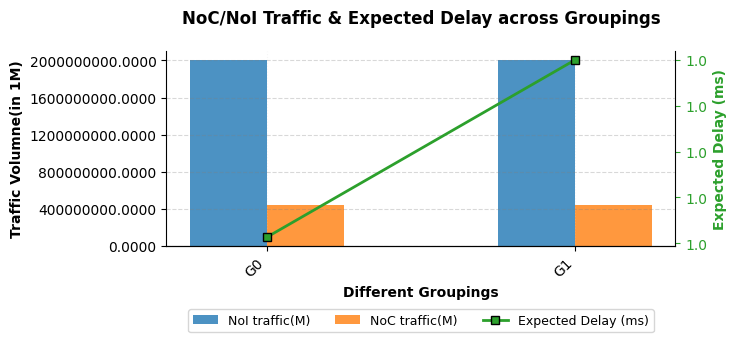


Top 2 Selected Points for LIF_T=2 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,15630531,27613444,0.99969,3168,1
1,G1,15630531,27613444,1.00000,3312,2



Running for LIF_T = 3
27
ERROR: Cannot allocate layers 49-52 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [49, 50, 51, 52]
Only covered layers 1-48 out of 52
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=3. Skipping this multiplier.
ERROR: Cannot allocate layers 49-52 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [49, 50, 51, 52]
Only covered layers 1-48 out of 52
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-9.591836734693878 at LIF_T=3. Skipping this multiplier.
ERROR: Cannot allocate layers 49-52 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [49, 50, 51, 52]
Only covered layers 1-48 out of 52
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-9.183673469387756 at LIF_T=3. Skipping this multiplier.


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,14728290,34831366,1.000000,3168,1
1,G1,14728290,34831366,0.985368,3312,2
2,G2,18943971,1105920,0.525571,11304,28


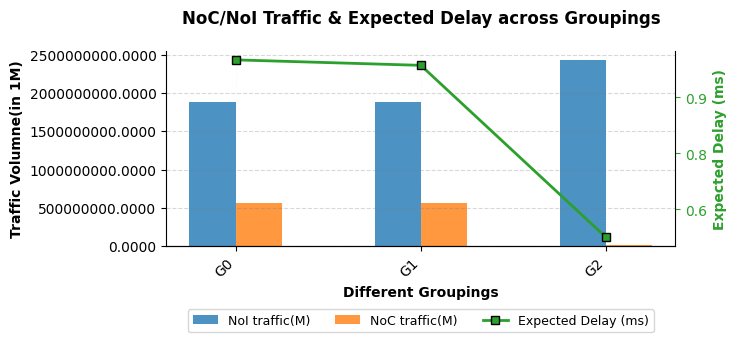


Top 3 Selected Points for LIF_T=3 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G2,18943971,1105920,0.525571,11304,28
1,G1,14728290,34831366,0.985368,3312,2
2,G0,14728290,34831366,1.000000,3168,1



Running for LIF_T = 4
30

Full Summary Table for LIF_T=4:


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,14442105,37120860,1.000000,3168,1
1,G1,14442105,37120860,0.980902,3312,2
2,G2,14081465,40005980,0.339559,3528,3
3,G3,18897892,1474560,0.573777,11376,27
4,G4,18897892,1474560,0.387609,14112,50
5,G5,18897892,1474560,0.357565,14184,51


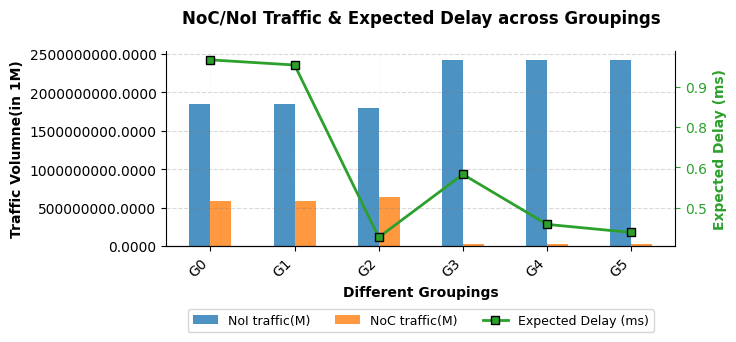


Top 4 Selected Points for LIF_T=4 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G2,14081465,40005980,0.339559,3528,3
1,G5,18897892,1474560,0.357565,14184,51
2,G4,18897892,1474560,0.387609,14112,50
3,G3,18897892,1474560,0.573777,11376,27



Running for LIF_T = 5
32

Full Summary Table for LIF_T=5:


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,14061837,40162994,1.000000,3168,1
1,G1,14061837,40162994,0.978075,3312,2
2,G2,18506851,4602880,0.599184,5616,14
3,G3,18695011,3097600,0.756023,14112,50
4,G4,18851811,1843200,0.419721,14184,51


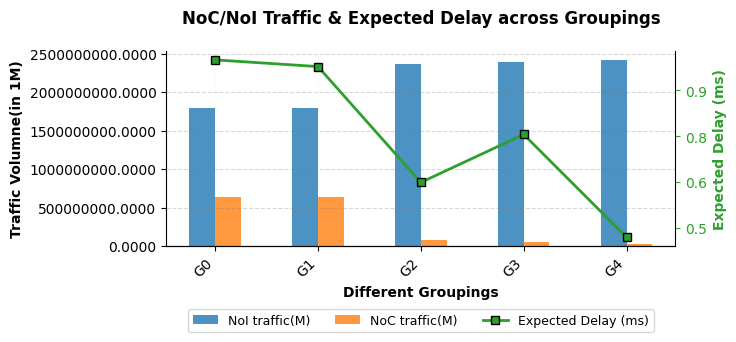


Top 4 Selected Points for LIF_T=5 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G4,18851811,1843200,0.419721,14184,51
1,G2,18506851,4602880,0.599184,5616,14
2,G3,18695011,3097600,0.756023,14112,50
3,G1,14061837,40162994,0.978075,3312,2



Running for LIF_T = 6
35

Full Summary Table for LIF_T=6:


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,18768611,2508800,0.910160,3168,1
1,G1,13875170,41656328,1.000000,3312,2
2,G2,13794850,42298886,0.763146,3528,3
3,G3,13794850,42298886,0.387596,3888,6
4,G4,18805730,2211840,0.378859,14112,50
5,G5,18805730,2211840,0.376676,14184,51


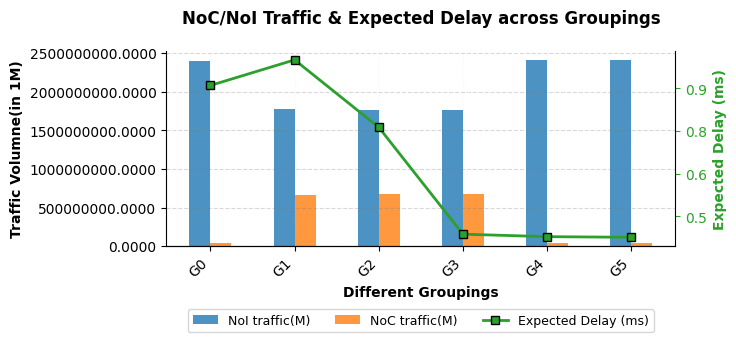


Top 4 Selected Points for LIF_T=6 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G5,18805730,2211840,0.376676,14184,51
1,G4,18805730,2211840,0.378859,14112,50
2,G3,13794850,42298886,0.387596,3888,6
3,G2,13794850,42298886,0.763146,3528,3



Running for LIF_T = 7
39

Full Summary Table for LIF_T=7:


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,18799972,2257920,0.805134,3168,1
1,G1,13776610,42444806,1.000000,3312,2
2,G2,18477410,4838400,0.661457,10872,25
3,G3,18759650,2580480,0.379346,14184,51


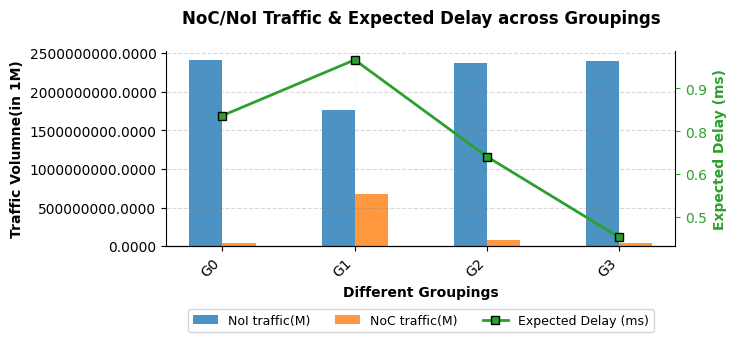


Top 4 Selected Points for LIF_T=7 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G3,18759650,2580480,0.379346,14184,51
1,G2,18477410,4838400,0.661457,10872,25
2,G0,18799972,2257920,0.805134,3168,1
3,G1,13776610,42444806,1.000000,3312,2



Running for LIF_T = 8
44

Full Summary Table for LIF_T=8:


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,18831330,2007040,0.921880,3168,1
1,G1,13647650,43476486,1.000000,3312,2
2,G2,13622690,43676164,0.688869,3528,3
3,G3,13622690,43676164,0.548297,4032,6
4,G4,18713570,2949120,0.514763,14112,50
5,G5,18713570,2949120,0.442349,14184,51


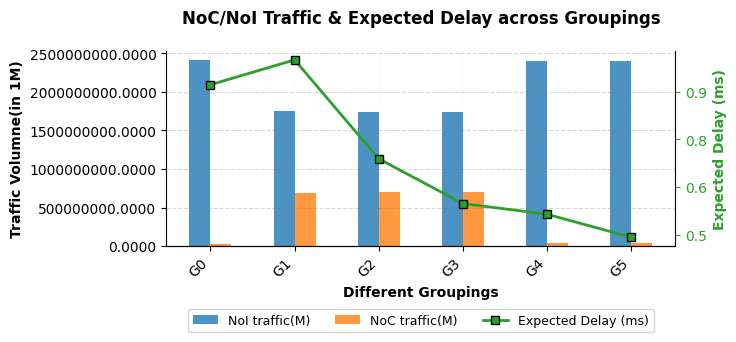


Top 4 Selected Points for LIF_T=8 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G5,18713570,2949120,0.442349,14184,51
1,G4,18713570,2949120,0.514763,14112,50
2,G3,13622690,43676164,0.548297,4032,6
3,G2,13622690,43676164,0.688869,3528,3



Running for LIF_T = 9
50

Full Summary Table for LIF_T=9:


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,18862690,1756160,0.916614,3168,1
1,G1,13549090,44264964,1.000000,3312,2
2,G2,18447970,5073920,0.563967,11160,27
3,G3,18447970,5073920,0.548862,14112,50
4,G4,18636610,3564800,0.644847,14184,51


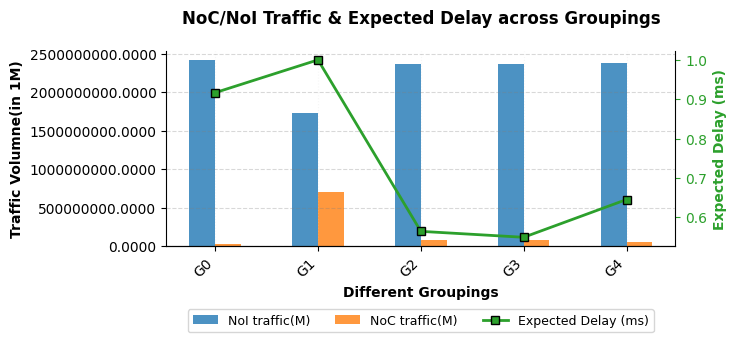


Top 4 Selected Points for LIF_T=9 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G3,18447970,5073920,0.548862,14112,50
1,G2,18447970,5073920,0.563967,11160,27
2,G4,18636610,3564800,0.644847,14184,51
3,G0,18862690,1756160,0.916614,3168,1



Running for LIF_T = 10
59

Full Summary Table for LIF_T=10:


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G0,18894051,1505280,0.929171,3168,1
1,G1,13498531,44669444,1.000000,3312,2
2,G2,13295651,46292484,0.478335,3528,3
3,G3,13436771,45163524,0.544424,3816,5
4,G4,13475491,44853764,0.450602,4464,9
5,G5,18285731,6371840,0.633382,14112,50
6,G6,18285731,6371840,0.633382,14184,51


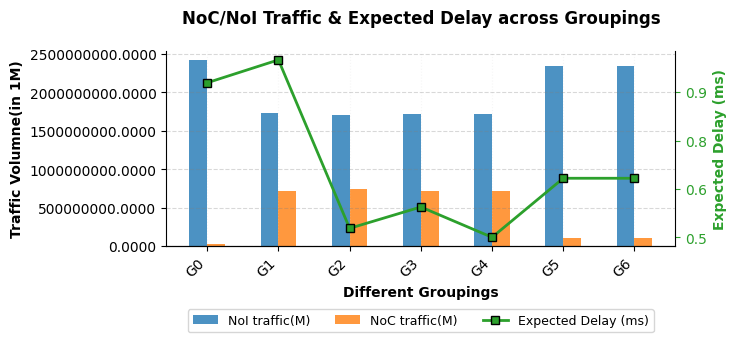


Top 4 Selected Points for LIF_T=10 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups
0,G4,13475491,44853764,0.450602,4464,9
1,G2,13295651,46292484,0.478335,3528,3
2,G3,13436771,45163524,0.544424,3816,5
3,G5,18285731,6371840,0.633382,14112,50



Running for LIF_T = 11
70
ERROR: Mapping requires 70 chiplets, mesh has 64
No valid groupings generated for multiplier=-10.0 at LIF_T=11. Skipping this multiplier.
ERROR: Mapping requires 70 chiplets, mesh has 64
No valid groupings generated for multiplier=-9.591836734693878 at LIF_T=11. Skipping this multiplier.
ERROR: Mapping requires 70 chiplets, mesh has 64
No valid groupings generated for multiplier=-9.183673469387756 at LIF_T=11. Skipping this multiplier.
ERROR: Mapping requires 70 chiplets, mesh has 64
No valid groupings generated for multiplier=-8.775510204081632 at LIF_T=11. Skipping this multiplier.
ERROR: Mapping requires 70 chiplets, mesh has 64
No valid groupings generated for multiplier=-8.36734693877551 at LIF_T=11. Skipping this multiplier.
ERROR: Mapping requires 70 chiplets, mesh has 64
No valid groupings generated for multiplier=-7.959183673469388 at LIF_T=11. Skipping this multiplier.
ERROR: Mapping requires 70 chiplets, mesh has 64
No valid groupings generated for

In [ ]:
#@title sweep through LIF_tiles and display everything (uses top_k_minima for selection)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from snn_mapper import SNNMapper

data = {"LIF_TILES": [], "Mem": [], "Expected_delay": []}
all_summary_dfs, all_top_n_dfs = {}, {}
all_M_sys_dfs, all_chiplet_dfs_lists = {}, {}
selected_groupings = {}
chiplet_configs_df={}
for LIF_T in LIF_T_list:
    print(f"\n{'='*60}\nRunning for LIF_T = {LIF_T}\n{'='*60}")

    mapper = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT-LIF_T-SRAM_T, X=xbar_size, P=100,
                       Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                       allow_break_columns=True, include_chiplets=False)
    mapper.tunable_params, mapper.xbars, mapper.IFMS, mapper.OFMS, mapper.TOPS, mapper.MEMS = mapper._calc_tunable_params()
    mapper.layer_output_sizes = dict(zip(range(1, len(mapper.OFMS) + 1), mapper.OFMS))
    mapper.chiplet_data = mapper._generate_chiplet_mapping()
    print(len(mapper.chiplet_data))
    SUM_LIF_MEM_UNGROUPED = np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).sum() * SRAM_KB_per_tile

    # ---- sweep threshold multipliers → candidate groupings
    R = {'multiplier': [], 'groups': [], 'cost': [], 'tiles': [], 'grouping': []}
    for mult in threshold_multipliers:
        gs = find_optimal_groupings_mesh_aware(
            len(mapper.IFMS), mesh_rows, mesh_cols, threshold_multiplier=mult, placement_strategy='exclusive',
            inter_cost=50,debug=False)

        # gs = group_layers_zero_safe(mapper=mapper,total_layers=len(mapper.MEMS),mesh_rows=mesh_rows, mesh_cols=mesh_cols,\
        #                                 LIF_T=LIF_T,SRAM_KB_per_tile=SRAM_KB_per_tile,placement_strategy='exclusive',\
        #                                 allow_reuse=False,threshold_multiplier=mult,inter_cost=4,debug=True)
        if not gs:
            print(f"No valid groupings generated for multiplier={mult} at LIF_T={LIF_T}. Skipping this multiplier.")
            continue

        R['grouping'].append(gs)
        R['multiplier'].append(mult)
        R['groups'].append(len(gs))
        R['cost'].append(sum(g.get('cost', 0) for g in gs))
        R['tiles'].append(sum(g['lif_tiles'] for g in gs))

    if not R['grouping']:
        print(f"\n WARNING: No valid groupings generated for LIF_T={LIF_T} across all threshold multipliers.")
        print(f"Skipping all analysis (traffic, plotting) for LIF_T={LIF_T}.\n")
        continue

    # ---- sort by (tiles, cost), then keep first per unique tiles
    tiles = np.asarray(R['tiles'], float)
    costs = np.asarray(R['cost'], float)
    groups = np.asarray(R['groups'], int)
    mults  = np.asarray(R['multiplier'], float)
    groupings = np.asarray(R['grouping'], object)

    order = np.lexsort((costs, tiles))  # primary=tiles, secondary=cost
    t, c, g, m, grp = tiles[order], costs[order], groups[order], mults[order], groupings[order]
    keep = np.r_[True, t[1:] != t[:-1]]
    #  include m[keep] here to keep tuple length = 5
    t, c, g, m, grp = t[keep], c[keep], g[keep], m[keep], grp[keep]

    unique_groupings   = list(grp)
    unique_tiles       = t.astype(int).tolist()
    unique_costs       = c.tolist()
    unique_num_groups  = g.astype(int).tolist()

    # ---- build chiplet configs & traffic
    all_chiplet_configs = [
        add_lif_tiles(mapper.chiplet_data, each_grouping, NT, LIF_T, NPE, mesh_rows, mesh_cols)
        for each_grouping in unique_groupings
    ]

    traffic_data = [
        calculate_traffic(gcfg, cfg, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                          mesh_rows=mesh_rows, mesh_cols=mesh_cols)
        for gcfg, cfg in zip(unique_groupings, all_chiplet_configs)
    ]

    # unpack
    inter_totals, intra_totals = map(np.array, zip(*[(td[0], td[1]) for td in traffic_data]))
    sys_dfs           = [td[2] for td in traffic_data]
    chiplet_dfs_lists = [td[3] for td in traffic_data]

    labels_arr = np.array([f"G{i}" for i in range(len(unique_groupings))])
    ###################################
    chiplet_configs_df[LIF_T] = pd.DataFrame({
    'group_ID': labels_arr,
    'chiplet_config': all_chiplet_configs,
    'Groupings': unique_groupings})
    ###################################
    # store matrices for this LIF_T
    all_M_sys_dfs[LIF_T]           = dict(zip(labels_arr, sys_dfs))
    all_chiplet_dfs_lists[LIF_T]   = dict(zip(labels_arr, chiplet_dfs_lists))

    # ---- Expected "delay" proxy: normalized Yan score (0..1) in label order
    out = yan_overlap_scores_normalized(all_M_sys_dfs, lif_t_idx=LIF_T, sample_cap=None, mode="max",all_M_chiplet_dfs=all_chiplet_dfs_lists)
    expected_delay_norm = np.array([out["norm"][gid] for gid in labels_arr], dtype=float)

    summary_df = pd.DataFrame({
        "group_ID": labels_arr,
        "NoI (pkts)": inter_totals,
        "NoC (pkts)": intra_totals,
        "Expected_delay(ms)": expected_delay_norm,            # proxy metric
        "LIF_MEM(KB)": np.array(unique_tiles) * SRAM_KB_per_tile,
        "Num Groups": unique_num_groups,
        "Groupings": unique_groupings
    })
    all_summary_dfs[LIF_T] = summary_df

    print(f"\nFull Summary Table for LIF_T={LIF_T}:")
    display(summary_df.drop(columns=['Groupings']))
    plot_grouping_traffic_delay(summary_df, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth)

    # ---- select top-k using top_k_minima (no pareto_plot)
    selected_ids = top_k_minima(
        summary_df,
        k=top_n,
        metric="Expected_delay(ms)",
        order_by="Num Groups",
        allow_plateaus=True,
        mode="hybrid"  # neighbor + per-bucket minima
    )
    top_n_df = (
        summary_df.loc[summary_df["group_ID"].isin(selected_ids)]
        .sort_values(by=["Expected_delay(ms)", "Num Groups"])
        .reset_index(drop=True)
    )
    all_top_n_dfs[LIF_T] = top_n_df

    print(f"\nTop {len(top_n_df)} Selected Points for LIF_T={LIF_T} (via top_k_minima):")
    display(top_n_df.drop(columns=['Groupings']))

# Optional: inspect stored matrices
# all_top_n_dfs
# all_M_sys_dfs
# all_chiplet_dfs_lists

In [ ]:
#@title run booksim and collect results
import pandas as pd
import numpy as np

# Initialize results list to collect both NoI and NoC latencies from each iteration
# You can later process this into a DataFrame or dict for analysis
results = []
top_NoI_percent=0.9
top_NoC_percent=0.9
min_traffic_packets=2
# Define mesh layouts (assuming mesh_rows, mesh_cols, NT are defined elsewhere)
NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]  # Sequential IDs 0 to padded_n-1 in row-major for NoI
noc_rows = int(np.sqrt(NT))
NoC_mesh_layout = [[(r * noc_rows + c) for c in range(noc_rows)] for r in range(noc_rows)]  # Assuming square NoC mesh per chiplet

for lif_t in LIF_T_list:
    if lif_t not in all_top_n_dfs:
        continue
    group_ids_to_check = list(all_top_n_dfs[lif_t]['group_ID'].values)
    if len(group_ids_to_check):
      for i in range(len(group_ids_to_check)):
        print(f"Processing lif_t={lif_t}, group_id={group_ids_to_check[i]}")
        top_NoC_matrices=[]
        M_sys_matrix = all_M_sys_dfs[lif_t][group_ids_to_check[i]]  # numpy array (system-wide traffic matrix)
        chiplet_matrices = all_chiplet_dfs_lists[lif_t][group_ids_to_check[i]]  # list of numpy arrays, e.g., chiplet_matrices[0] for chiplet 0
        for each_chiplet_matrix in chiplet_matrices:
          each_chiplet_matrix_top_99,  _  = split_top_rest(each_chiplet_matrix, percent=top_NoC_percent)
          top_NoC_matrices.append(each_chiplet_matrix_top_99)
        NoI_matrix_top_99,  _  = split_top_rest(M_sys_matrix, percent=top_NoI_percent)

        # Scale traffic matrices
        chiplet_scaled_dfs, chiplet_scaling_factors, \
        system_scaled_df, system_scaling_factor = scale_traffic_matrices(
            system_matrix=NoI_matrix_top_99, chiplet_matrices=top_NoC_matrices, minimum_traffic=min_traffic_packets)

        # Create NoC mesh layouts (repeated for each chiplet; adjust if layouts differ)
        NoC_mesh_layouts = [NoC_mesh_layout] * len(chiplet_scaled_dfs)


        # Prepare communication matrix for NoI (system-wide)
        communication_matrix = system_scaled_df.values  # Numerical numpy array from scaled DataFrame

        # Run BookSim for NoI (system-wide)
        NoI_latency_raw,NoI_power_raw = run_booksim_NoI(communication_matrix, NoI_mesh_layout)
        # Run BookSim for NoC (per-chiplet)
        NoC_latencies_raw,NoC_powers_raw = run_booksim_NoC(chiplet_scaled_dfs, NoC_mesh_layouts)

        NoC_latencies_scaled = np.array(NoC_latencies_raw)*np.array(chiplet_scaling_factors)

        # Scale NoI latency by the system scaling factor to normalize
        NoI_latency_scaled = NoI_latency_raw * system_scaling_factor

        # Retrieve 'LIF_MEM(KB)' and 'Groupings' from all_top_n_dfs[lif_t] for the current group_id
        current_row = all_top_n_dfs[lif_t][all_top_n_dfs[lif_t]['group_ID'] == group_ids_to_check[i]]
        lif_mem_kb = current_row['LIF_MEM(KB)'].values[0]  # Assuming it's a single value
        groupings = current_row['Groupings'].values[0]  # Assuming it's a single value

        # Append to results (e.g., as a dict for context; adjust NoC_latency handling if it's a list/single value)
        results.append({
            'lif_t': lif_t,
            'group_id': group_ids_to_check[i],
            'LIF_MEM(KB)': lif_mem_kb,
            'Groupings': groupings,
            'NoC_latency_ms': NoC_cycle_time_ns*NoC_latencies_scaled.sum()/1e6,  # Assuming scalar; if list, store accordingly
            'NoI_latency_ms': NoC_cycle_time_ns*NoI_latency_scaled/1e6,
            'Total_latency_ms': (NoC_cycle_time_ns*NoC_latencies_scaled.sum() + NoC_cycle_time_ns*NoI_latency_scaled)/1e6,
            'NoI_NoC_power': np.array(NoC_powers_raw).sum()+NoI_power_raw
        })

        print(f"  - NoC Latency ms(scaled): {NoC_cycle_time_ns*NoC_latencies_scaled.sum()/1e6}")
        print(f"  - NoI Latency ms(scaled): {NoC_cycle_time_ns*NoI_latency_scaled/1e6}")
        print(f"  - Total Power(raw): {np.array(NoC_powers_raw).sum()+NoI_power_raw}")

print("All processing complete.")

# Create DataFrame from collected results
results_df = pd.DataFrame(results)
display(results_df)

Processing lif_t=2, group_id=G0
BookSim output for NoI saved to out_system_level.txt
BookSim output saved for NoC to out_chiplet_0.txt
BookSim output saved for NoC to out_chiplet_1.txt
BookSim output saved for NoC to out_chiplet_2.txt
BookSim output saved for NoC to out_chiplet_3.txt
BookSim output saved for NoC to out_chiplet_4.txt
BookSim output saved for NoC to out_chiplet_5.txt
BookSim output saved for NoC to out_chiplet_6.txt
BookSim output saved for NoC to out_chiplet_7.txt
BookSim output saved for NoC to out_chiplet_8.txt
BookSim output saved for NoC to out_chiplet_9.txt
BookSim output saved for NoC to out_chiplet_10.txt
BookSim output saved for NoC to out_chiplet_11.txt
BookSim output saved for NoC to out_chiplet_12.txt
BookSim output saved for NoC to out_chiplet_13.txt
BookSim output saved for NoC to out_chiplet_14.txt
BookSim output saved for NoC to out_chiplet_15.txt
BookSim output saved for NoC to out_chiplet_16.txt
BookSim output saved for NoC to out_chiplet_17.txt
BookSim

,lif_t,group_id,LIF_MEM(KB),Groupings,NoC_latency_ms,NoI_latency_ms,Total_latency_ms,NoI_NoC_power
0,2,G0,3168,"[{'start_layer': 1, 'end_layer': 52, 'lif_tile...",0.399977,0.464065,0.864042,9.855006
1,2,G1,3312,"[{'start_layer': 1, 'end_layer': 50, 'lif_tile...",0.399977,0.473285,0.873262,9.858616
2,3,G2,11304,"[{'start_layer': 1, 'end_layer': 1, 'lif_tiles...",0.063228,0.304694,0.367922,17.054973
3,3,G1,3312,"[{'start_layer': 1, 'end_layer': 50, 'lif_tile...",0.499326,0.419503,0.918829,9.936359
4,3,G0,3168,"[{'start_layer': 1, 'end_layer': 52, 'lif_tile...",0.499326,0.422356,0.921682,9.928529
5,4,G2,3528,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...",0.591345,0.305281,0.896626,10.277567
6,4,G5,14184,"[{'start_layer': 1, 'end_layer': 1, 'lif_tiles...",0.068390,0.280986,0.349375,17.115331
7,4,G4,14112,"[{'start_layer': 1, 'end_layer': 1, 'lif_tiles...",0.068390,0.282303,0.350692,17.197431
8,4,G3,11376,"[{'start_layer': 1, 'end_layer': 1, 'lif_tiles...",0.068388,0.307041,0.375429,15.613144
9,5,G4,14184,"[{'start_layer': 1, 'end_layer': 1, 'lif_tiles...",0.070970,0.278790,0.349761,15.762730


BookSim output for NoI saved to out_system_level.txt
		Global LIF Case
NoI Latency:15.441162239999999 ms,NoC Latency:0 ms, LIF Memory=3168 KB, Total Power: 14.0655


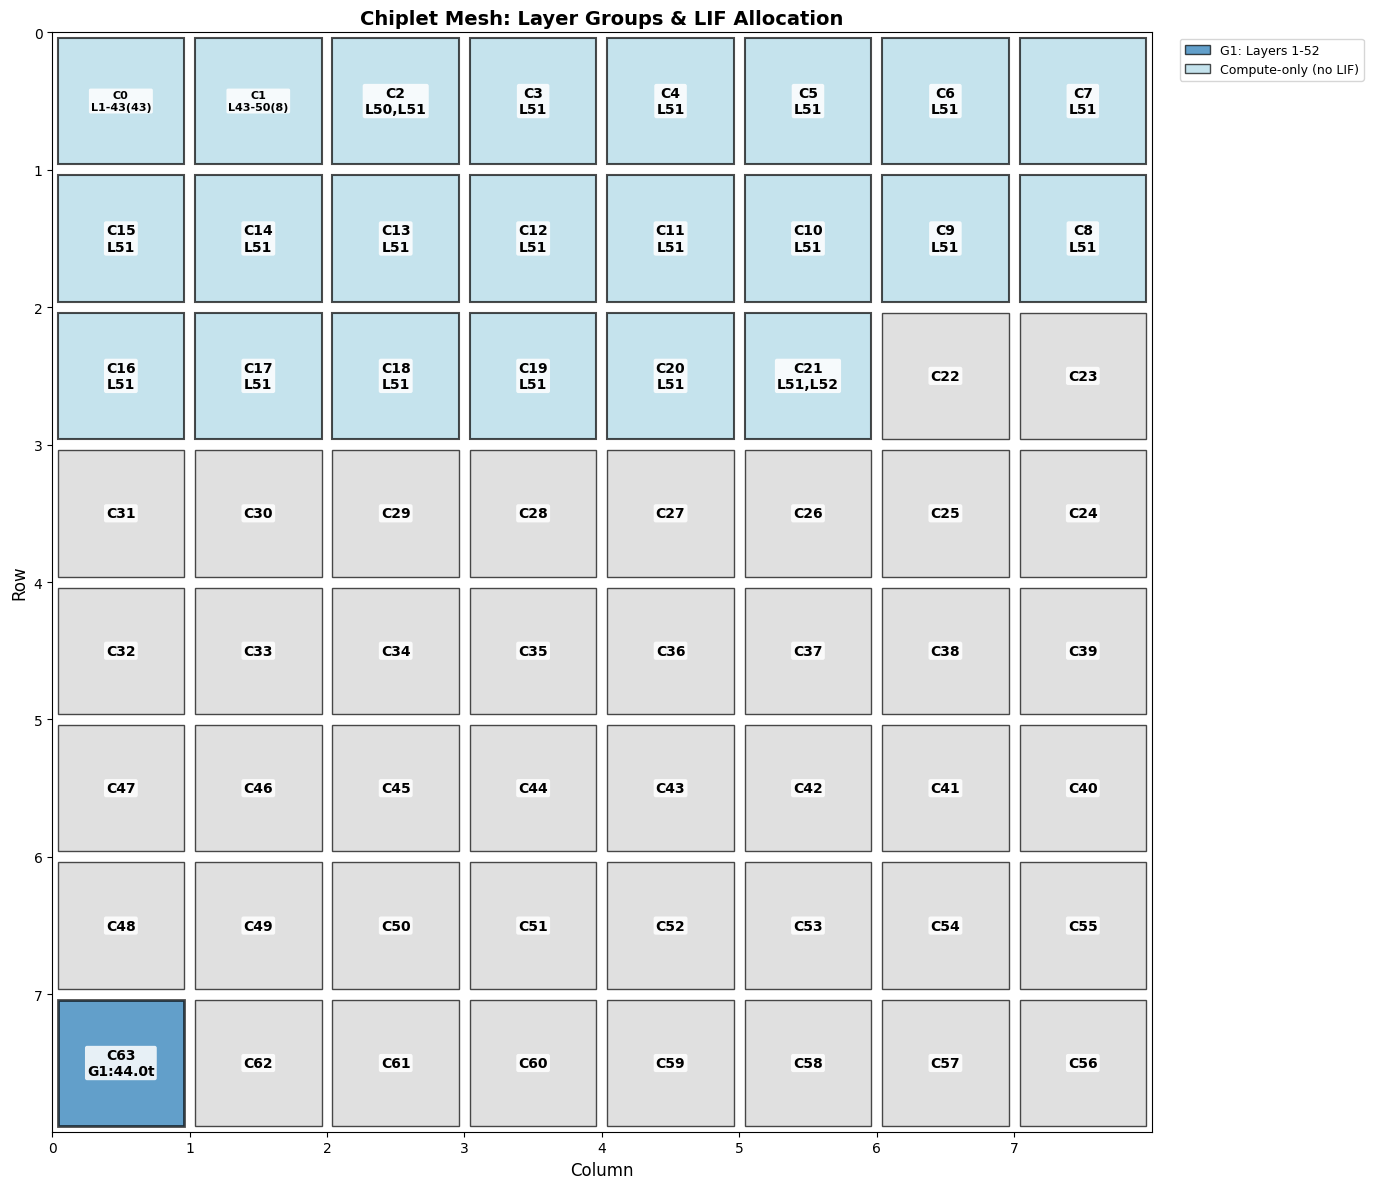

In [ ]:
#@title GLobal LIF Module Case
from snn_mapper import SNNMapper
import copy
mapper_global = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT, X=xbar_size, P=100,
                       Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                       allow_break_columns=True, include_chiplets=False)
mapper_global.tunable_params, mapper_global.xbars, mapper_global.IFMS, mapper_global.OFMS, mapper_global.TOPS, mapper_global.MEMS = mapper_global._calc_tunable_params()
mapper_global.layer_output_sizes = dict(zip(range(1, len(mapper_global.OFMS) + 1), mapper_global.OFMS))
mapper_global.chiplet_data = mapper_global._generate_chiplet_mapping()

LIF_needed=np.ceil(np.array(mapper_global.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).max()

LIF_chiplet={'Layers_filled': [],
  'Crossbars_filled_respective_layer': [],
  'Crossbars_remaining_respective_layer': [],
  'Layer_tile_distribution': {'LIF0': {i: NPE for i in range(44)}},
  'Empty_crossbars': NT*NPE}
EMPTY = {
    'Layers_filled': [],
    'Crossbars_filled_respective_layer': [],
    'Crossbars_remaining_respective_layer': [],
    'Layer_tile_distribution': {},
    'Empty_crossbars': NT*NPE
}
global_grp=[{'start_layer': 1,
  'end_layer': len(mapper_global.weights),
  'lif_tiles': LIF_needed,
  'lif_distribution': [(mesh_rows * mesh_cols-1, LIF_needed)],
  'cost': 0.0}]


# ---- build chiplet configs & traffic
cc = copy.deepcopy(mapper_global.chiplet_data)
nn = mesh_rows * mesh_cols - len(mapper_global.chiplet_data) -1
cc += ([EMPTY] * nn) +[LIF_chiplet]
cc
_,_,global_system_df,global_chiplet_dfs =  calculate_traffic(global_grp, cc, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,\
                          mesh_rows=mesh_rows, mesh_cols=mesh_cols)
system_df_top_99,  _  = split_top_rest(global_system_df, percent=top_NoI_percent)
NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]  # Sequential IDs 0 to padded_n-1 in row-major for NoI
# Scale traffic matrices
_, _, \
system_df_top_99_scaled, system_df_top_99_scaling_factor = scale_traffic_matrices(system_matrix=system_df_top_99, chiplet_matrices=global_chiplet_dfs,\
                                                                                  minimum_traffic=10)
# Run BookSim for NoI (system-wide)
global_NoI_latency_raw,global_NoI_power_raw = run_booksim_NoI(system_df_top_99_scaled.values, NoI_mesh_layout)
global_NoI_latency_ms = global_NoI_latency_raw * system_df_top_99_scaling_factor*NoI_cycle_time_ns/1e6
global_LIF_needed=LIF_needed*SRAM_KB_per_tile
print("="*50+"\n\t\tGlobal LIF Case\n"+"="*50)
print(f'NoI Latency:{global_NoI_latency_ms} ms,NoC Latency:{0} ms, LIF Memory={global_LIF_needed} KB, Total Power: {global_NoI_power_raw}')
_=visualize_groups(global_grp, cc,mesh_rows, mesh_cols, LIF_T=LIF_needed,max_lines=2)

BookSim output for NoI saved to out_system_level.txt
		4-Corner Global LIF Case
NoI Latency:14.327866559999999 ms,NoC Latency:0 ms, LIF Memory=3168 KB, Total Power: 13.0322


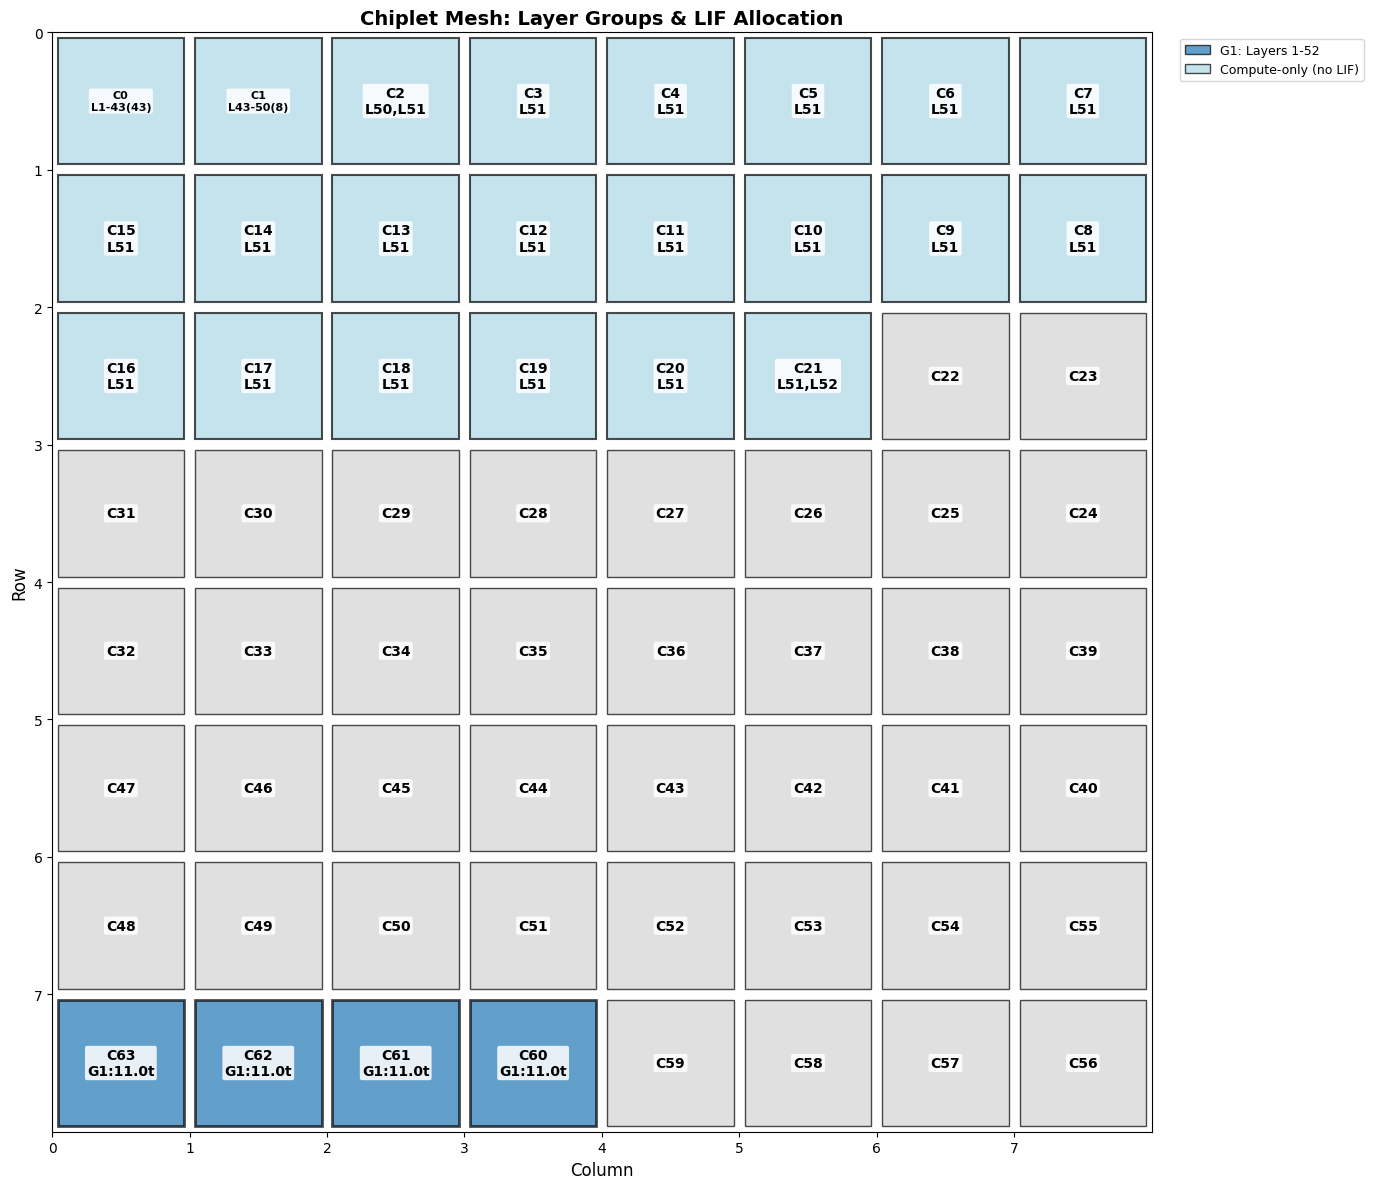

In [ ]:
#@title 4 corner GLobal LIF Module Case
import copy
mapper_global = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT, X=xbar_size, P=100,
                       Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                       allow_break_columns=True, include_chiplets=False)
mapper_global.tunable_params, mapper_global.xbars, mapper_global.IFMS, mapper_global.OFMS, mapper_global.TOPS, mapper_global.MEMS = mapper_global._calc_tunable_params()
mapper_global.layer_output_sizes = dict(zip(range(1, len(mapper_global.OFMS) + 1), mapper_global.OFMS))
mapper_global.chiplet_data = mapper_global._generate_chiplet_mapping()

LIF_needed=np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).max()
tiles_per_lif = np.ceil(LIF_needed / 4).astype(int)

LIF_chiplet={'Layers_filled': [],
  'Crossbars_filled_respective_layer': [],
  'Crossbars_remaining_respective_layer': [],
  'Layer_tile_distribution': {'LIF0': {i: NPE for i in range(tiles_per_lif)}},
  'Empty_crossbars': NT*NPE}
EMPTY = {
    'Layers_filled': [],
    'Crossbars_filled_respective_layer': [],
    'Crossbars_remaining_respective_layer': [],
    'Layer_tile_distribution': {},
    'Empty_crossbars': NT*NPE
}
global_grp = [{
    'start_layer': 1,
    'end_layer': len(mapper_global.weights),
    'lif_tiles': LIF_needed,
    'lif_distribution': [
        (mesh_rows * mesh_cols - 4, tiles_per_lif),
        (mesh_rows * mesh_cols - 3, tiles_per_lif),
        (mesh_rows * mesh_cols - 2, tiles_per_lif),
        (mesh_rows * mesh_cols - 1, tiles_per_lif)
    ],
    'cost': 0.0
}]

# ---- build chiplet configs & traffic
cc = copy.deepcopy(mapper_global.chiplet_data)
nn = mesh_rows * mesh_cols - len(mapper_global.chiplet_data) -4
cc += ([EMPTY] * nn) +([LIF_chiplet]*4)

_,_,global_system_df,global_chiplet_dfs =  calculate_traffic(global_grp, cc, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,\
                          mesh_rows=mesh_rows, mesh_cols=mesh_cols)
system_df_top_99,  _  = split_top_rest(global_system_df, percent=top_NoI_percent)
NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]  # Sequential IDs 0 to padded_n-1 in row-major for NoI
# Scale traffic matrices
_, _, \
system_df_top_99_scaled, system_df_top_99_scaling_factor = scale_traffic_matrices(system_matrix=system_df_top_99, chiplet_matrices=global_chiplet_dfs,\
                                                                                  minimum_traffic=10)
# Run BookSim for NoI (system-wide)
global_NoI_latency_raw,global_NoI_power_raw = run_booksim_NoI(system_df_top_99_scaled.values, NoI_mesh_layout)
four_corner_global_NoI_latency_ms = global_NoI_latency_raw * system_df_top_99_scaling_factor*NoI_cycle_time_ns/1e6
four_corner_global_LIF_needed = LIF_needed*SRAM_KB_per_tile
print("="*50+"\n\t\t4-Corner Global LIF Case\n"+"="*50)
print(f'NoI Latency:{four_corner_global_NoI_latency_ms} ms,NoC Latency:{0} ms, LIF Memory={four_corner_global_LIF_needed} KB, Total Power: {global_NoI_power_raw}')
_=visualize_groups(global_grp, cc,mesh_rows, mesh_cols, LIF_T=tiles_per_lif,max_lines=2)

Computed Pareto/best/top_n without plotting (plot=False).
Computed Pareto/best/top_n without plotting (plot=False).
Computed Pareto/best/top_n without plotting (plot=False).
Computed Pareto/best/top_n without plotting (plot=False).
Computed Pareto/best/top_n without plotting (plot=False).
Computed Pareto/best/top_n without plotting (plot=False).
Computed Pareto/best/top_n without plotting (plot=False).
Computed Pareto/best/top_n without plotting (plot=False).
Computed Pareto/best/top_n without plotting (plot=False).


,lif_t,group_id,LIF_MEM(KB),Groupings,NoC_latency_ms,NoI_latency_ms,Total_latency_ms,NoI_NoC_power,Num_groups
0,2,G0,3168,"[{'start_layer': 1, 'end_layer': 52, 'lif_tile...",0.399977,0.464065,0.864042,9.855006,1
1,3,G1,3312,"[{'start_layer': 1, 'end_layer': 50, 'lif_tile...",0.499326,0.419503,0.918829,9.936359,2
2,4,G3,11376,"[{'start_layer': 1, 'end_layer': 1, 'lif_tiles...",0.068388,0.307041,0.375429,15.613144,27
3,5,G2,5616,"[{'start_layer': 1, 'end_layer': 1, 'lif_tiles...",0.134188,0.274982,0.409171,11.628610,14
4,6,G3,3888,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...",0.659688,0.300948,0.960637,10.980723,6
5,7,G0,3168,"[{'start_layer': 1, 'end_layer': 52, 'lif_tile...",0.047421,0.350134,0.397555,11.954118,1
6,8,G3,4032,"[{'start_layer': 1, 'end_layer': 30, 'lif_tile...",0.704691,0.338043,1.042734,11.842726,6
7,9,G0,3168,"[{'start_layer': 1, 'end_layer': 52, 'lif_tile...",0.050056,0.345744,0.395800,12.749664,1
8,10,G4,4464,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...",0.716161,0.331914,1.048076,13.429406,9


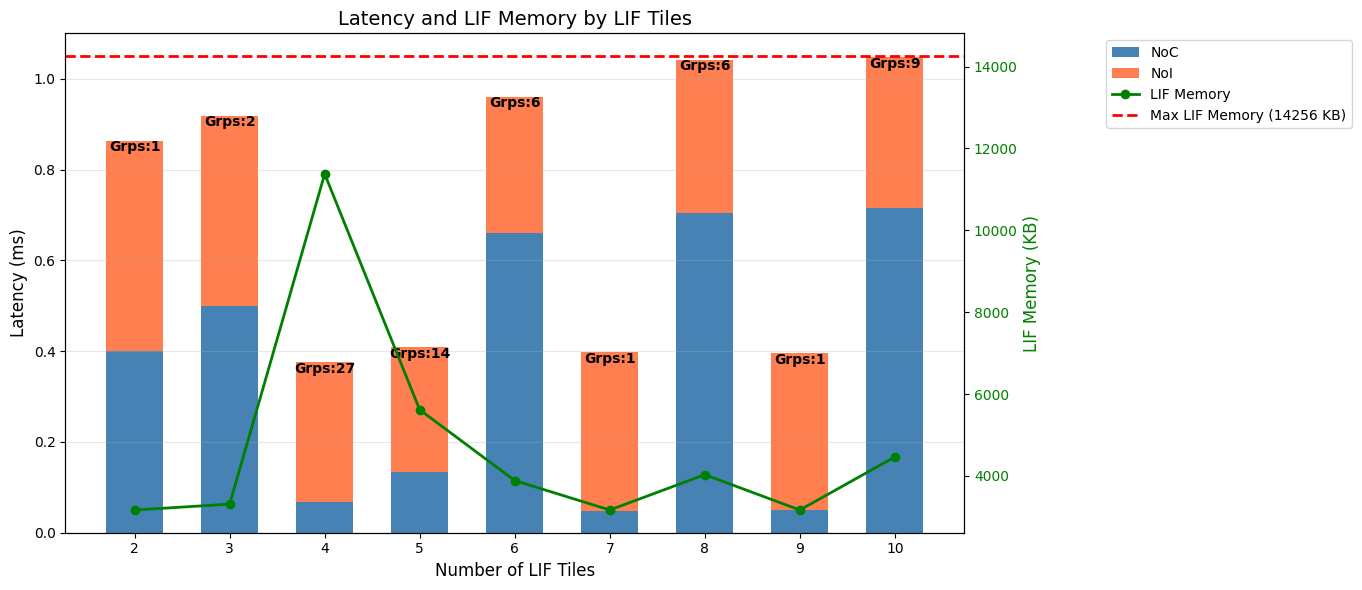

In [ ]:
#@title Run pareto front selection and ablation plot for LIF_tiles sweep
import matplotlib.pyplot as plt
import numpy as np

best_rows = []
for lif in LIF_T_list:
    rows = results_df[results_df["lif_t"] == lif].reset_index(drop=True)
    if len(rows) == 0:
        continue
    elif len(rows) == 1:
        rec = rows.iloc[0].to_dict()
    else:
        # multiple candidates → run pareto to pick best
        bp = pareto_plot(
            rows,
            x_col="LIF_MEM(KB)",
            y_col="Total_latency_ms",
            method="equal_weightage",
            top_n=top_n,
            highlight_top_n=True,
            annotate_all=False,
            scale_scatter=0.5,
            plot=False
        )['best_point']
        rec = bp if isinstance(bp, dict) else bp.to_dict()

    rec["lif_t"] = lif
    best_rows.append(rec)

winners_df = pd.DataFrame(best_rows).reset_index(drop=True)
winners_df["Num_groups"] = winners_df["Groupings"].apply(lambda g: len(g))
display(winners_df)

##############################################
# Prepare data
lif_tiles = winners_df['lif_t'].values
noc_latency = winners_df['NoC_latency_ms'].values
noi_latency = winners_df['NoI_latency_ms'].values
num_groups = winners_df['Num_groups'].values
lif_mem = winners_df['LIF_MEM(KB)'].values

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Set x positions
x = np.arange(len(lif_tiles))
width = 0.6

# Create stacked bars on left y-axis
bar1 = ax1.bar(x, noc_latency, width, label='NoC', color='steelblue')
bar2 = ax1.bar(x, noi_latency, width, bottom=noc_latency, label='NoI', color='coral')

# Annotate with number of groups (skip NaN cases)
for i, (bar, groups) in enumerate(zip(bar2, num_groups)):
    height = noc_latency[i] + noi_latency[i]
    if not np.isnan(groups):
        ax1.text(bar.get_x() + bar.get_width()/2., height-0.03,
                 f'Grps:{int(groups)}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize left y-axis
ax1.set_xlabel('Number of LIF Tiles', fontsize=12)
ax1.set_ylabel('Latency (ms)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(lif_tiles)
ax1.grid(axis='y', alpha=0.3)

# Create second y-axis for line plot
ax2 = ax1.twinx()
line = ax2.plot(x, lif_mem, color='green', marker='o', linewidth=2,
                markersize=6, label='LIF Memory')

# Add horizontal dotted line for max LIF memory
ax2.axhline(y=SUM_LIF_MEM_UNGROUPED, color='red', linestyle='--',
            linewidth=2, label=f'Max LIF Memory ({SUM_LIF_MEM_UNGROUPED} KB)')

ax2.set_ylabel('LIF Memory (KB)', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Combine legends and place outside
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           bbox_to_anchor=(1.15, 1), frameon=True)

ax1.set_title('Latency and LIF Memory by LIF Tiles', fontsize=14)

plt.tight_layout()
plt.show()

Computed Pareto/best/top_n without plotting (plot=False).
Final selected case of LIF:9
		Comparison cases


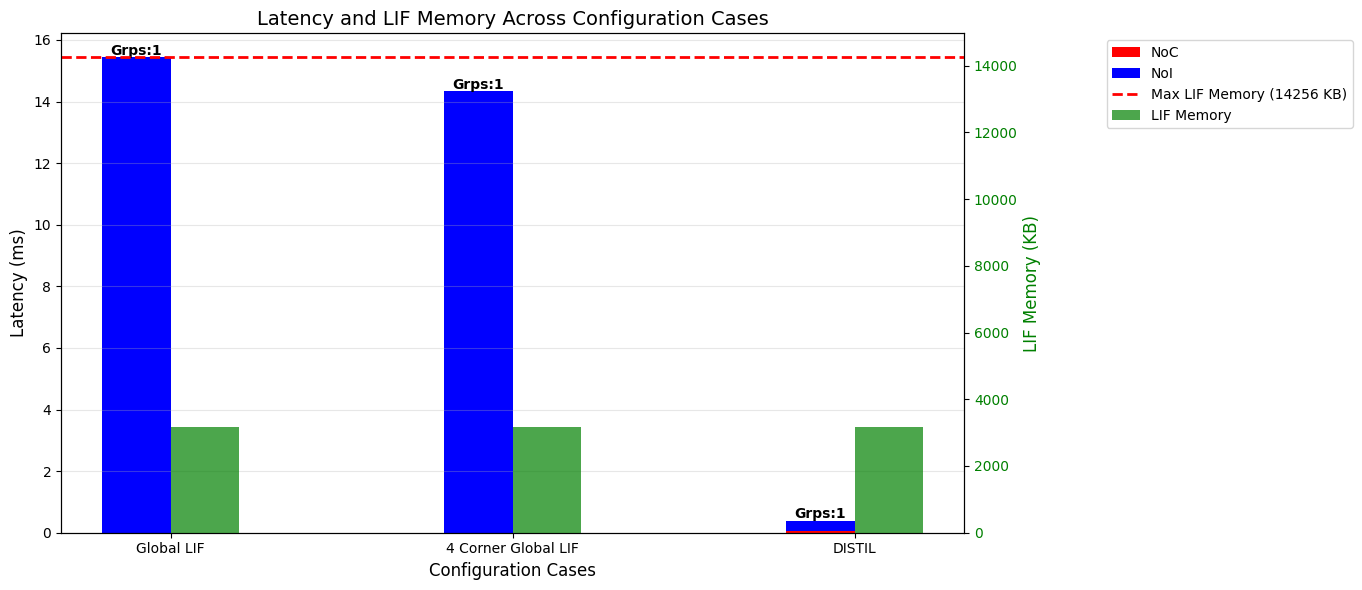

		DISTIL Chiplet mapping


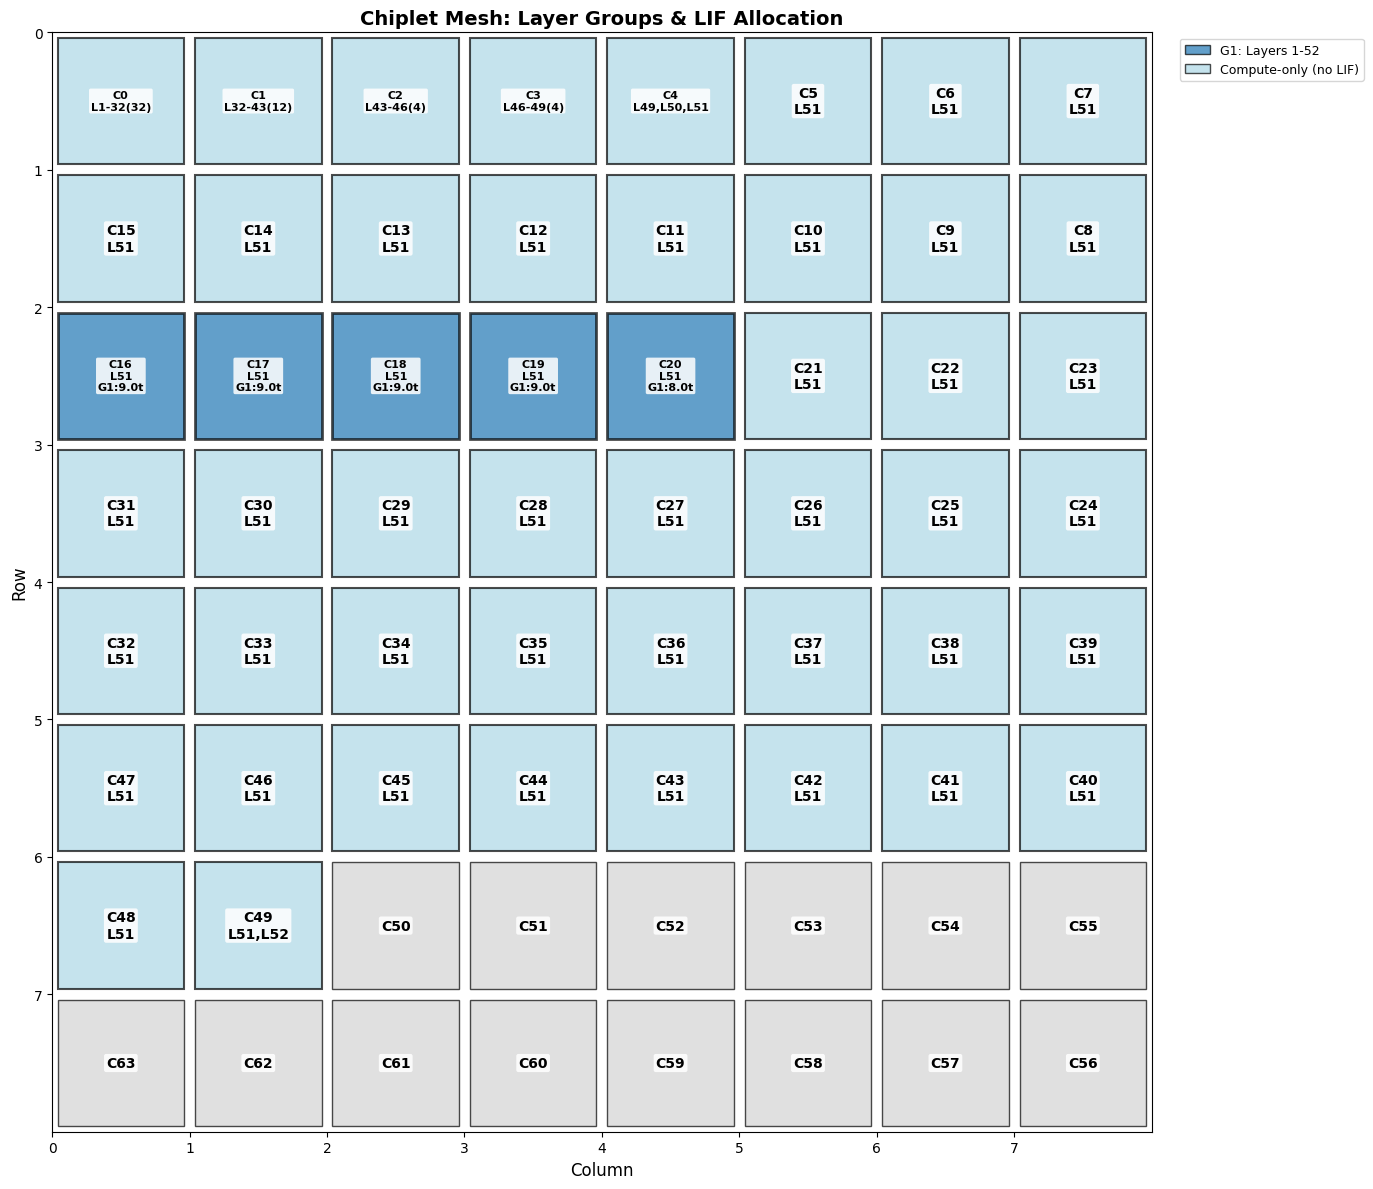

In [ ]:
auto_choose=True
LIF_TILE_CASE =9
####################################################################################
if auto_choose:
  final_result = pareto_plot(winners_df,x_col="LIF_MEM(KB)",y_col="Total_latency_ms",method="knee",\
                           top_n=top_n,highlight_top_n=True,annotate_all=False,scale_scatter=0.5,plot=False)['best_point']
else:
  final_result = winners_df[winners_df['lif_t'] == LIF_TILE_CASE].iloc[0]
print(f"Final selected case of LIF:{final_result['lif_t']}")
group_id = final_result['group_id']
chiplet_mapping = chiplet_configs_df[LIF_TILE_CASE][chiplet_configs_df[LIF_TILE_CASE]['group_ID'] == group_id]['chiplet_config'].values[0]
grp=final_result['Groupings']
# Example usage (replace with your actual data):
noc_latency = [0, 0, final_result['NoC_latency_ms']]
noi_latency = [global_NoI_latency_ms, four_corner_global_NoI_latency_ms, final_result['NoI_latency_ms']]
lif_mem = [global_LIF_needed, four_corner_global_LIF_needed, final_result['LIF_MEM(KB)']]
num_groups = [1, 1, final_result['Num_groups']]
cases = ['Global LIF', '4 Corner Global LIF', 'DISTIL']
print("="*50+"\n\t\tComparison cases\n"+"="*50)
fig, ax1 = plot_config_comparison(noc_latency, noi_latency, lif_mem, num_groups, cases, SUM_LIF_MEM_UNGROUPED)
print("="*50+"\n\t\tDISTIL Chiplet mapping\n"+"="*50)
_=visualize_groups(grp, chiplet_mapping,mesh_rows, mesh_cols, LIF_T=lif,max_lines=6)